<a href="https://colab.research.google.com/github/Astrages4/ML_labs/blob/main/lab2/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №2: Временные ряды

**Цель:** Восстановить аккуратный согласованный датафрейм, по максимуму исправить ошибки в данных. Обучить модели предсказывать температуру на 1 неделю вперед.

Испортируем библиотеки:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Обработка исходного excel-файла
С помощью инструментов самого Excel проведем первичную обработку нашего датасета: перекрасим текст из белого в черный, удалим пустые страницы, сделаем скрытые страницы видимыми, вернем на место фрагменты таблицы, которые были смещены в сторону, поставим их в конец таблицы.
На втором листе была вставлена картинка и немного съехали данные. Вернем их на место.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


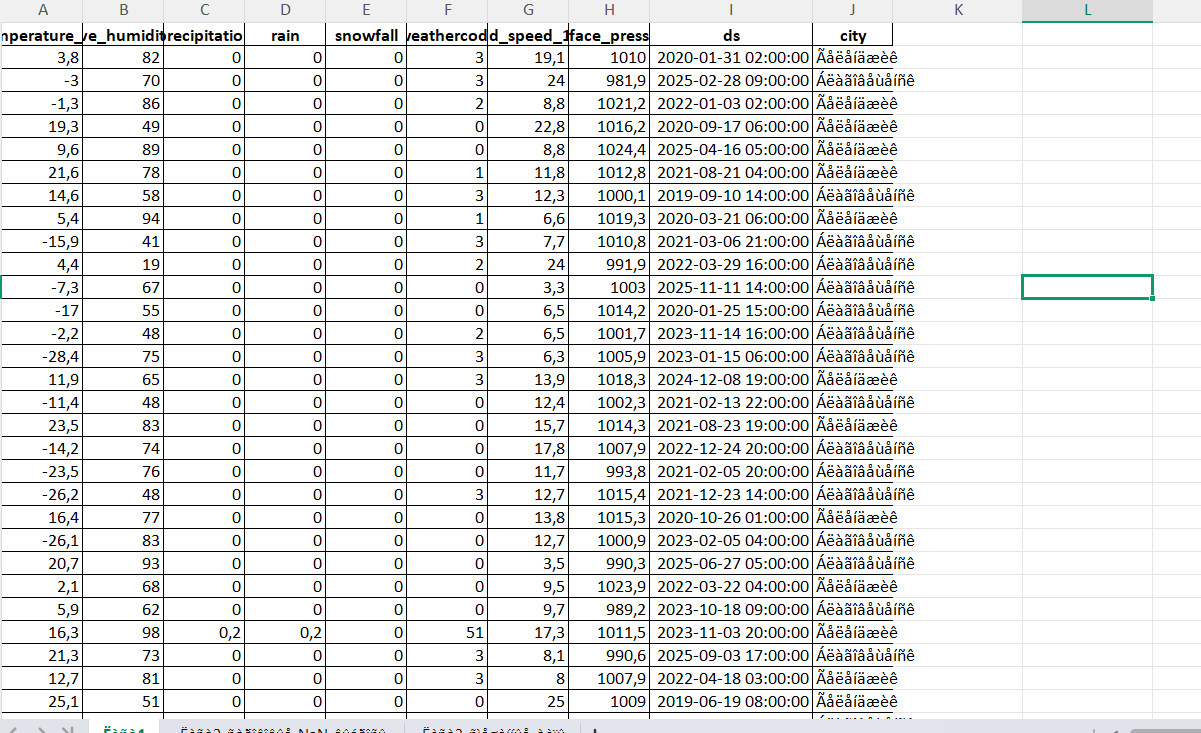

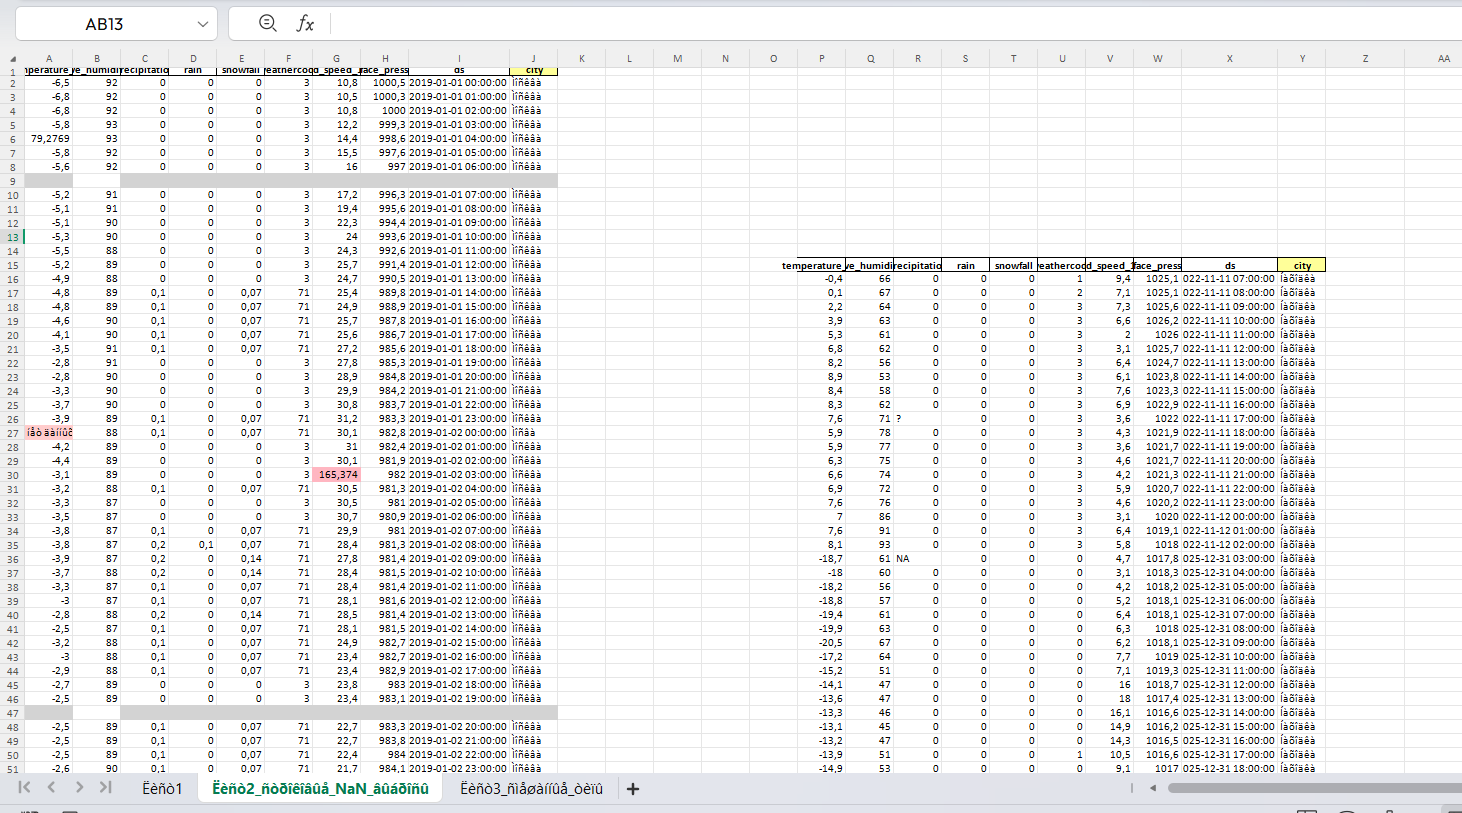

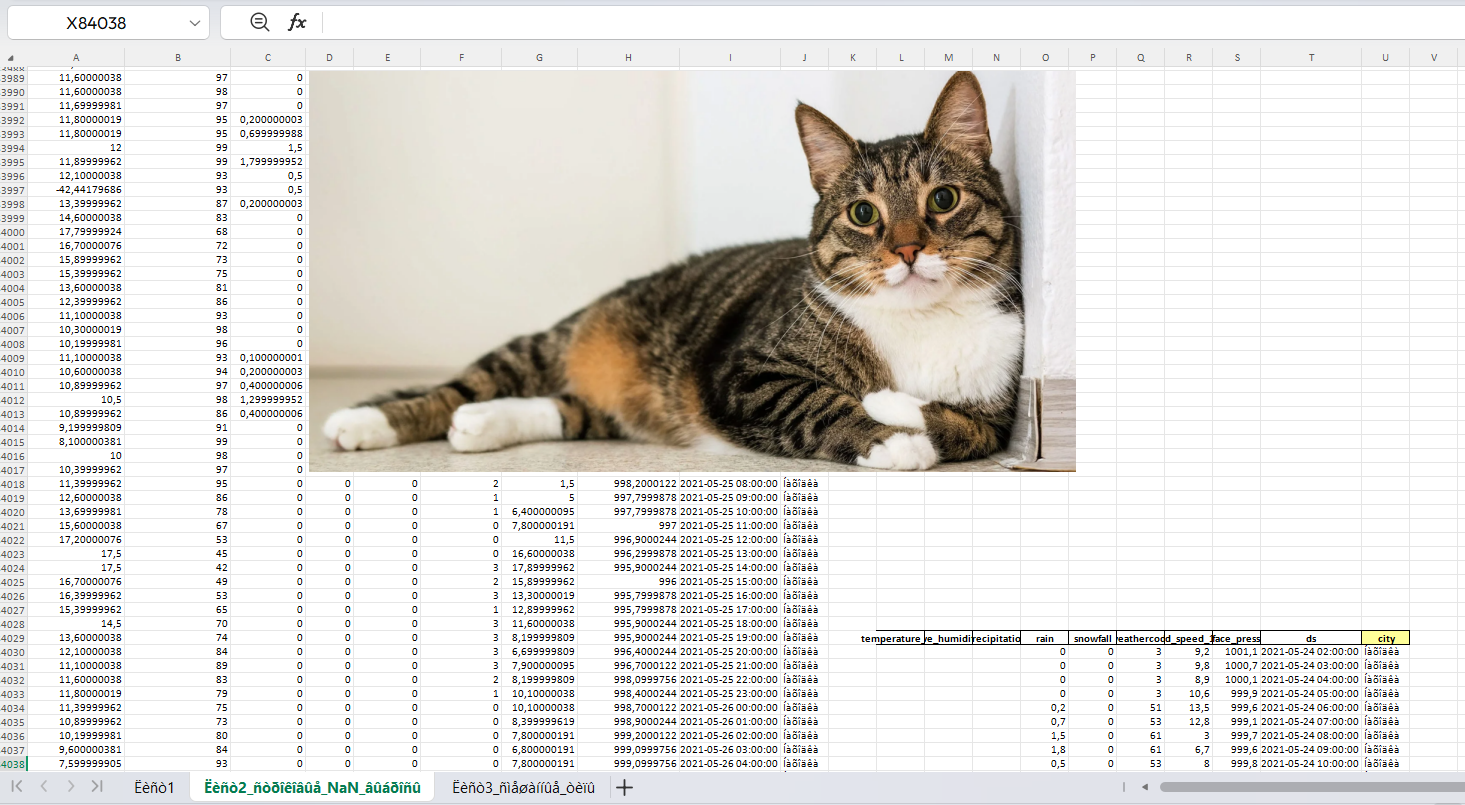

Считываем наш датасет, каждый лист превращаем в отдельный датафрейм:

In [3]:
all_sheets = pd.read_excel('/content/drive/MyDrive/have_fun.xlsx', sheet_name=None)
df_1, df_2, df_3 = all_sheets.values()

In [4]:
df_3.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.00,3,23.5,1015.200012,2019-01-01 00:00:00,Ñàíêò-Ïåòåðáóðã
1,-1.9,83.0,0,0.0,0.00,3,26,1013.200012,2019-01-01 01:00:00,Ñàíêò-Ïåòåðáóðã
2,-2,85.0,0,0.0,0.00,3,26.200001,1011.700012,2019-01-01 02:00:00,Ñàíêò-Ïåòåðáóðã
3,-2.3,86.0,0,0.0,0.00,3,26.9,1009.900024,2019-01-01 03:00:00,Ñàíêò-Ïåòåðáóðã
4,-2.3,86.0,0.2,0.0,0.14,71,27.9,1007.700012,2019-01-01 04:00:00,Ñàíêò-Ïåòåðáóðã


В колонке "city" сбита кодировка:

In [5]:
df_1['city'] = df_1['city'].apply(lambda x: x.encode('latin-1').decode('cp1251') if isinstance(x, str) else x)
df_2['city'] = df_2['city'].apply(lambda x: x.encode('latin-1').decode('cp1251') if isinstance(x, str) else x)
df_3['city'] = df_3['city'].apply(lambda x: x.encode('latin-1').decode('cp1251') if isinstance(x, str) else x)

In [6]:
df_3.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.00,3,23.5,1015.200012,2019-01-01 00:00:00,Санкт-Петербург
1,-1.9,83.0,0,0.0,0.00,3,26,1013.200012,2019-01-01 01:00:00,Санкт-Петербург
2,-2,85.0,0,0.0,0.00,3,26.200001,1011.700012,2019-01-01 02:00:00,Санкт-Петербург
3,-2.3,86.0,0,0.0,0.00,3,26.9,1009.900024,2019-01-01 03:00:00,Санкт-Петербург
4,-2.3,86.0,0.2,0.0,0.14,71,27.9,1007.700012,2019-01-01 04:00:00,Санкт-Петербург


Остальные столбцы имеют формат даты или числа, поэтому в них кодировку не проверяем (даже если где-то среди них затясался текст - это в любом случае ошибка).

Чтобы предсказывать температуру на неделю вперед, будет целесообразно сделать отдельные модели для каждого города. Узнаем, какие города есть в таблице:

In [7]:
cities_1 = df_1['city'].value_counts()
print(cities_1)
cities_2 = df_2['city'].value_counts()
print(cities_2)
cities_3 = df_3['city'].value_counts()
print(cities_3)

city
Благовещенск     61659
Геленджик        61587
Геленджикк         248
БЛАГОВЕЩЕНСК       245
Геленджи           242
благовещенск       239
Благовещенскк      230
геленджик          228
Благовещенс        226
ГЕЛЕНДЖИК          220
Name: count, dtype: int64
city
Находка          61387
Москва           61364
Геленджик           33
Благовещенск        31
Мосва                1
Благовещенскк        1
Геленджикк           1
Name: count, dtype: int64
city
Санкт-Петербург    61368
Сочи               61364
Сычи                   2
Счи                    1
Соч                    1
Name: count, dtype: int64


Во втором листе также есть пропуск города:

In [8]:
print(df_2['city'].unique())

['Москва' nan 'Мосва' 'Находка' 'Благовещенск' 'Геленджик' 'Благовещенскк'
 'Геленджикк']


Приведем названия к аккуратному виду:

In [9]:
# уберем строки, в которых город не указан - мы не сможем их использовать
df_2.dropna(subset=['city'], inplace=True)

df_1.loc[df_1['city'].str.contains('гелендж', case=False), 'city'] = 'Геленджик'
df_1.loc[df_1['city'].str.contains('благовещ', case=False), 'city'] = 'Благовещенск'

df_2.loc[df_2['city'].str.contains('гелендж', case=False), 'city'] = 'Геленджик'
df_2.loc[df_2['city'].str.contains('благовещ', case=False), 'city'] = 'Благовещенск'
df_2.loc[df_2['city'].str.contains('мос', case=False), 'city'] = 'Москва'

df_3.loc[df_3['city'].str.contains('соч|чи', case=False), 'city'] = 'Сочи'

cities_1 = df_1['city'].value_counts()
print(cities_1)
cities_2 = df_2['city'].value_counts()
print(cities_2)
cities_3 = df_3['city'].value_counts()
print(cities_3)

city
Благовещенск    62599
Геленджик       62525
Name: count, dtype: int64
city
Находка         61387
Москва          61365
Геленджик          34
Благовещенск       32
Name: count, dtype: int64
city
Санкт-Петербург    61368
Сочи               61368
Name: count, dtype: int64


Проверим типы данных столбцов количество пропусков:

In [10]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125124 entries, 0 to 125123
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        123249 non-null  float64       
 1   relative_humidity_2m  125124 non-null  int64         
 2   precipitation         123877 non-null  float64       
 3   rain                  125124 non-null  float64       
 4   snowfall              125124 non-null  float64       
 5   weathercode           125124 non-null  int64         
 6   wind_speed_10m        123872 non-null  float64       
 7   surface_pressure      125124 non-null  float64       
 8   ds                    125124 non-null  datetime64[ns]
 9   city                  125124 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 9.5+ MB


In [11]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122818 entries, 0 to 125275
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122138 non-null  object        
 1   relative_humidity_2m  122818 non-null  float64       
 2   precipitation         122130 non-null  object        
 3   rain                  122818 non-null  float64       
 4   snowfall              122818 non-null  float64       
 5   weathercode           122818 non-null  float64       
 6   wind_speed_10m        122468 non-null  object        
 7   surface_pressure      122818 non-null  float64       
 8   ds                    122817 non-null  datetime64[ns]
 9   city                  122818 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 10.3+ MB


Изначально не заметил, что в листе 2 была фотография кота, так что memory usage конкретно для этого листа был слишком большим по сравнению с другими двумя листами(больше 20 МБ).

In [12]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122736 entries, 0 to 122735
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122731 non-null  object        
 1   relative_humidity_2m  122731 non-null  float64       
 2   precipitation         122487 non-null  object        
 3   rain                  122736 non-null  float64       
 4   snowfall              122736 non-null  float64       
 5   weathercode           122736 non-null  object        
 6   wind_speed_10m        122736 non-null  object        
 7   surface_pressure      122736 non-null  float64       
 8   ds                    122736 non-null  datetime64[ns]
 9   city                  122736 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 9.4+ MB


Видим, что преобразование типов необходимо, но мы сделаем его позже, после деления датафреймов по городам и сортировки по дате, т.к. нам потребуется заполнять пропуски линейной интерполяцией и сейчас мы не сможем сделать это корректно.

Датафрейм под каждый город:

In [29]:
df_gel1 = df_1[df_1['city'] == 'Геленджик']
df_gel2 = df_2[df_2['city'] == 'Геленджик']
df_gel = pd.concat([df_gel1, df_gel2], ignore_index=True)

df_blag1 = df_1[df_1['city'] == 'Благовещенск']
df_blag2 = df_2[df_2['city'] == 'Благовещенск']
df_blag = pd.concat([df_blag1, df_blag2], ignore_index=True)

df_mos = df_2[df_2['city'] == 'Москва']
df_nahod = df_2[df_2['city'] == 'Находка']
df_spb = df_3[df_3['city'] == 'Санкт-Петербург']
df_sochi = df_3[df_3['city'] == 'Сочи']

dfs = [df_gel, df_blag, df_mos, df_nahod, df_spb, df_sochi]
for df in dfs:
    print(df['city'].value_counts())

city
Геленджик    62559
Name: count, dtype: int64
city
Благовещенск    62631
Name: count, dtype: int64
city
Москва    61365
Name: count, dtype: int64
city
Находка    61387
Name: count, dtype: int64
city
Санкт-Петербург    61368
Name: count, dtype: int64
city
Сочи    61368
Name: count, dtype: int64


## Обработка дубликатов, пропусков и аномалий

Уберем строки, в которых нет даты (при этом мы знаем, что тип столбца с датой везде в порядке), отсортируем строки по дате, уберем дубликаты (в нашем случае они не несут новой информации, т.к. это записи об одном и том же моменте времени):

In [37]:
for df in dfs:
    df.dropna(subset=['ds'], inplace=True)
    df.sort_values(by='ds', inplace=True)
    df.drop_duplicates(subset=['ds'], inplace=True)

/tmp/ipykernel_517/1761297840.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['ds'], inplace=True)
/tmp/ipykernel_517/1761297840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by='ds', inplace=True)
/tmp/ipykernel_517/1761297840.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(subset=['ds'], inplace=True)
/tmp/ipykernel_517/1761297840.py:2: SettingWithCopyWarning: 
A value

In [38]:
df_sochi.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
61368,4.6,89,0.2,0.2,0.0,51,8.0,1024.699951,2019-01-01 00:00:00,Сочи
61369,4.5,88,0.2,0.2,0.0,51,7.6,1025.000000,2019-01-01 01:00:00,Сочи
61370,4.5,90,0.2,0.2,0.0,51,6.5,1025.400024,2019-01-01 02:00:00,Сочи
61371,5.2,86,0.1,0.1,0.0,51,9.7,1025.500000,2019-01-01 03:00:00,Сочи
61372,4.8,90,0.0,0.0,0.0,1,6.1,1025.500000,2019-01-01 04:00:00,Сочи


Теперь преобразуем типы данных столбцов и заполним пропуски:

In [39]:
numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain',
                    'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']
int_numerics = ['weathercode', 'relative_humidity_2m']

for df in dfs:
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

    for col in int_numerics:
        df[col] = df[col].round().astype(int)

    print(f"{df['city'].iloc[0]}:")
    for col in df.columns.tolist():
        missing = df[col].isna().sum()
        print(f"{col}: {missing} пропусков, тип: {df[col].dtype}")

Геленджик:
temperature_2m: 0 пропусков, тип: float64
relative_humidity_2m: 0 пропусков, тип: int64
precipitation: 0 пропусков, тип: float64
rain: 0 пропусков, тип: float64
snowfall: 0 пропусков, тип: float64
weathercode: 0 пропусков, тип: int64
wind_speed_10m: 0 пропусков, тип: float64
surface_pressure: 0 пропусков, тип: float64
ds: 0 пропусков, тип: datetime64[ns]
city: 0 пропусков, тип: object
Благовещенск:
temperature_2m: 0 пропусков, тип: float64
relative_humidity_2m: 0 пропусков, тип: int64
precipitation: 0 пропусков, тип: float64
rain: 0 пропусков, тип: float64
snowfall: 0 пропусков, тип: float64
weathercode: 0 пропусков, тип: int64
wind_speed_10m: 0 пропусков, тип: float64
surface_pressure: 0 пропусков, тип: float64
ds: 0 пропусков, тип: datetime64[ns]
city: 0 пропусков, тип: object
Москва:
temperature_2m: 0 пропусков, тип: float64
relative_humidity_2m: 0 пропусков, тип: int64
precipitation: 0 пропусков, тип: float64
rain: 0 пропусков, тип: float64
snowfall: 0 пропусков, тип: fl

/tmp/ipykernel_517/3583550562.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')
/tmp/ipykernel_517/3583550562.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].interpolate(method='linear', limit_direction='both')
/tmp/ipykernel_517/3583550562.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [40]:
df_gel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61368 entries, 22675 to 19796
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   temperature_2m        61368 non-null  float64       
 1   relative_humidity_2m  61368 non-null  int64         
 2   precipitation         61368 non-null  float64       
 3   rain                  61368 non-null  float64       
 4   snowfall              61368 non-null  float64       
 5   weathercode           61368 non-null  int64         
 6   wind_speed_10m        61368 non-null  float64       
 7   surface_pressure      61368 non-null  float64       
 8   ds                    61368 non-null  datetime64[ns]
 9   city                  61368 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 5.2+ MB


Проверим, является ли ряд равномерным

In [41]:
interrupted_dfs = []
for df in dfs:
    df = df.sort_values('ds')
    diffs = df['ds'].diff().dropna()

    is_uniform = len(diffs.unique()) == 1
    print(f"Ряд равномерный: {is_uniform}")

    if not is_uniform:
        print(df['city'][0])
        interrupted_dfs.append(df)
        print(f"Частота: {diffs.mode()[0]}")

Ряд равномерный: True
Ряд равномерный: True
Ряд равномерный: False
Москва
Частота: 0 days 01:00:00
Ряд равномерный: True
Ряд равномерный: True
Ряд равномерный: True


In [42]:
for df in interrupted_dfs:
    df = df.sort_values('ds').reset_index(drop=True)

    start_date = df['ds'].min()
    end_date = df['ds'].max()

    full_range = pd.date_range(
        start=start_date,
        end=end_date,
        freq='h',
        name='ds'
    )
    df_full = pd.DataFrame(full_range)

    df_full = df_full.merge(df, on='ds', how='left')

    # Линейная интерполяция для всех числовых столбцов
    df_full[numeric_cols] = df_full[numeric_cols].interpolate(
        method='linear',
        limit_direction='both'
    )
    for col in int_numerics:
        df_full[col] = df_full[col].round().astype(int)

    df_full['city'] = df_full['city'].ffill().bfill()

    print(f"Записей до: {len(df)}")
    print(f"Записей после: {len(df_full)}")

    # Проверка непрерывности
    time_diff = df_full['ds'].diff()
    gaps = time_diff[time_diff > pd.Timedelta(hours=1)]
    print(f"\nОсталось разрывов: {len(gaps)}")
    print(f"Пропущенных значений после обработки: {df_full.isna().sum().sum()}")

    df_mos = df_full.copy()


Записей до: 61364
Записей после: 61368

Осталось разрывов: 0
Пропущенных значений после обработки: 0


In [43]:
df_mos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ds                    61368 non-null  datetime64[ns]
 1   temperature_2m        61368 non-null  float64       
 2   relative_humidity_2m  61368 non-null  int64         
 3   precipitation         61368 non-null  float64       
 4   rain                  61368 non-null  float64       
 5   snowfall              61368 non-null  float64       
 6   weathercode           61368 non-null  int64         
 7   wind_speed_10m        61368 non-null  float64       
 8   surface_pressure      61368 non-null  float64       
 9   city                  61368 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 4.7+ MB


Теперь все датафреймы непрерывные:

In [44]:
dfs = [df_gel, df_blag, df_mos, df_nahod, df_spb, df_sochi]
for df in dfs:
    df = df.sort_values('ds')
    diffs = df['ds'].diff().dropna()

    is_uniform = len(diffs.unique()) == 1
    print(f"Ряд равномерный: {is_uniform}")

    if not is_uniform:
        print(df['city'][0])
        print(f"Частота: {diffs.mode()[0]}")

Ряд равномерный: True
Ряд равномерный: True
Ряд равномерный: True
Ряд равномерный: True
Ряд равномерный: True
Ряд равномерный: True


In [45]:
df_nahod.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
62574,-13.4,58,0.0,0.0,0.0,0,5.2,1025.500000,2019-01-01 00:00:00,Находка
62575,-13.1,56,0.0,0.0,0.0,0,6.5,1025.199951,2019-01-01 01:00:00,Находка
62576,-13.5,58,0.0,0.0,0.0,0,5.5,1024.900024,2019-01-01 02:00:00,Находка
62577,-13.9,59,0.0,0.0,0.0,0,5.0,1024.900024,2019-01-01 03:00:00,Находка
62578,-14.9,64,0.0,0.0,0.0,0,4.6,1024.099976,2019-01-01 04:00:00,Находка


In [46]:
city_dfs = {
    'Москва': df_mos,
    'Находка': df_nahod,
    'Благовещенск': df_blag,
    'Геленджик': df_gel,
    'Санкт-Петербург': df_spb,
    'Сочи': df_sochi
}

Обработаем выбросы:

In [47]:
for city, city_df in city_dfs.items():
    print(city)
    city_df.drop(columns=['city'], inplace=True)
    print(city_df.describe())

Москва
                        ds  temperature_2m  relative_humidity_2m  \
count                61368    61368.000000          61368.000000   
mean   2022-07-02 11:30:00        6.909072             75.755980   
min    2019-01-01 00:00:00      -49.983136             16.000000   
25%    2020-10-01 05:45:00       -1.000000             65.000000   
50%    2022-07-02 11:30:00        6.500000             80.000000   
75%    2024-04-01 17:15:00       15.400000             89.000000   
max    2025-12-31 23:00:00       79.974214            100.000000   
std                    NaN       11.844257             16.976699   

       precipitation          rain      snowfall   weathercode  \
count   61368.000000  61368.000000  61368.000000  61368.000000   
mean        3.978064      0.056908      0.014363     12.807913   
min         0.000000      0.000000      0.000000      0.000000   
25%         0.000000      0.000000      0.000000      1.000000   
50%         0.000000      0.000000      0.000000  

/tmp/ipykernel_517/2084735513.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_df.drop(columns=['city'], inplace=True)
/tmp/ipykernel_517/2084735513.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_df.drop(columns=['city'], inplace=True)
/tmp/ipykernel_517/2084735513.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_df.drop(columns=['city'], inplace=True)


Во-первых, изменим с помощью линейной интерполяции такие значения температуры и давления, которые отличаются от двух соседних больше, чем на 10, а также невозможные значения температуры

In [48]:
for city, city_df in city_dfs.items():
    diff_prev = city_df['temperature_2m'].diff().abs()
    diff_next = city_df['temperature_2m'].diff(-1).abs()
    outliers = (diff_prev > 10) & (diff_next > 10)
    city_df.loc[outliers, 'temperature_2m'] = np.nan
    if city == "Москва":
        extr = abs(city_df['temperature_2m']) > 38
        city_df.loc[extr, 'temperature_2m'] = np.nan
    elif city == "Находка":
        extr = (city_df['temperature_2m'] > 37) | (city_df['temperature_2m'] < -27)
        city_df.loc[extr, 'temperature_2m'] = np.nan
    city_df['temperature_2m'] = city_df['temperature_2m'].interpolate(method='linear')

    diff_prev_pr = city_df['surface_pressure'].diff().abs()
    diff_next_pr = city_df['surface_pressure'].diff(-1).abs()
    outliers = (diff_prev_pr > 10) & (diff_next_pr > 10)
    city_df.loc[outliers, 'surface_pressure'] = np.nan
    city_df['surface_pressure'] = city_df['surface_pressure'].interpolate(method='linear')
    print(city)
    print(city_df.describe())

Москва
                        ds  temperature_2m  relative_humidity_2m  \
count                61368    61368.000000          61368.000000   
mean   2022-07-02 11:30:00        6.831630             75.755980   
min    2019-01-01 00:00:00      -31.000000             16.000000   
25%    2020-10-01 05:45:00       -0.900000             65.000000   
50%    2022-07-02 11:30:00        6.500000             80.000000   
75%    2024-04-01 17:15:00       15.300000             89.000000   
max    2025-12-31 23:00:00       34.799999            100.000000   
std                    NaN       10.586261             16.976699   

       precipitation          rain      snowfall   weathercode  \
count   61368.000000  61368.000000  61368.000000  61368.000000   
mean        3.978064      0.056908      0.014363     12.807913   
min         0.000000      0.000000      0.000000      0.000000   
25%         0.000000      0.000000      0.000000      1.000000   
50%         0.000000      0.000000      0.000000  

/tmp/ipykernel_517/3208780749.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_df['temperature_2m'] = city_df['temperature_2m'].interpolate(method='linear')
/tmp/ipykernel_517/3208780749.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_df['surface_pressure'] = city_df['surface_pressure'].interpolate(method='linear')
/tmp/ipykernel_517/3208780749.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

       temperature_2m  relative_humidity_2m  precipitation          rain  \
count    61368.000000          61368.000000   61368.000000  61368.000000   
mean         6.790916             79.036941       0.081622      0.062754   
min        -28.799999             15.000000       0.000000      0.000000   
25%          0.100000             71.000000       0.000000      0.000000   
50%          5.900000             83.000000       0.000000      0.000000   
75%         14.600000             90.000000       0.000000      0.000000   
max         35.700001            100.000000      17.299999     17.299999   
std          9.623664             15.123751       0.330721      0.316817   

           snowfall   weathercode  wind_speed_10m  surface_pressure  \
count  61368.000000  61368.000000    61368.000000      61368.000000   
mean       0.013324     13.612502       14.593976       1012.383721   
min        0.000000      0.000000        0.000000        964.099976   
25%        0.000000      1.0000

In [49]:
df_blag.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds
2935,-13.7,56,0.0,0.0,0.0,3,12.600000,1008.700012,2019-01-01 00:00:00
26556,-13.2,56,0.0,0.0,0.0,3,16.299999,1008.500000,2019-01-01 01:00:00
56289,-12.5,56,0.0,0.0,0.0,3,18.000000,1008.299988,2019-01-01 02:00:00
11509,-12.1,56,0.0,0.0,0.0,3,18.100000,1007.900024,2019-01-01 03:00:00
30297,-11.9,56,0.0,0.0,0.0,3,17.600000,1007.500000,2019-01-01 04:00:00


## Анализ временного ряда

Для начала посмотрим, как вообще менялась температура: и сами значения, и скользящее среднее за год:

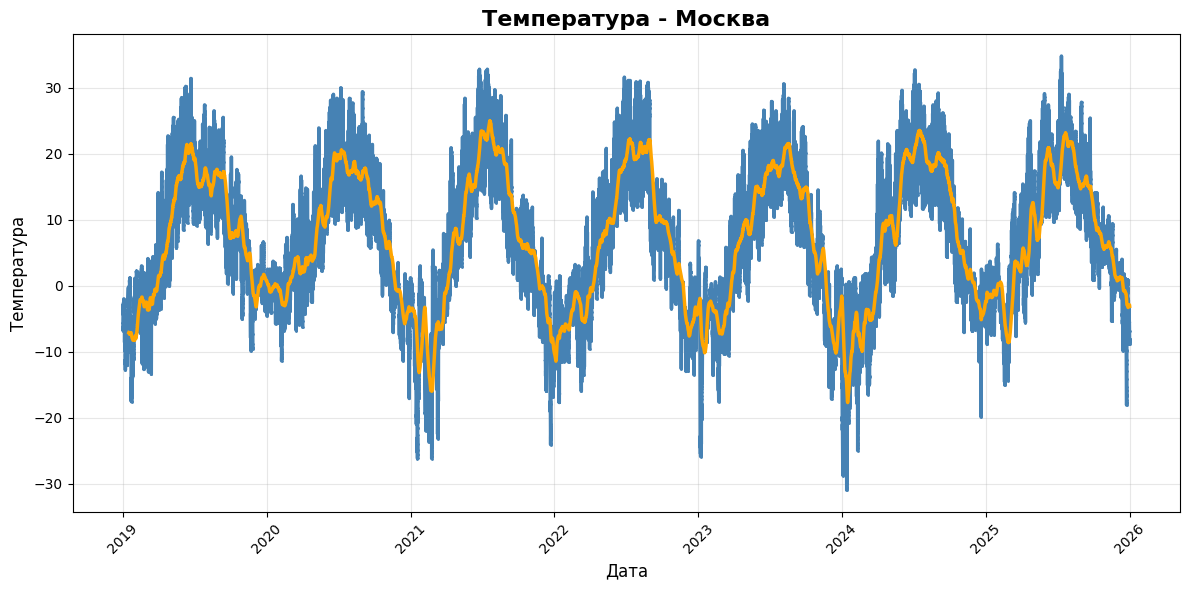

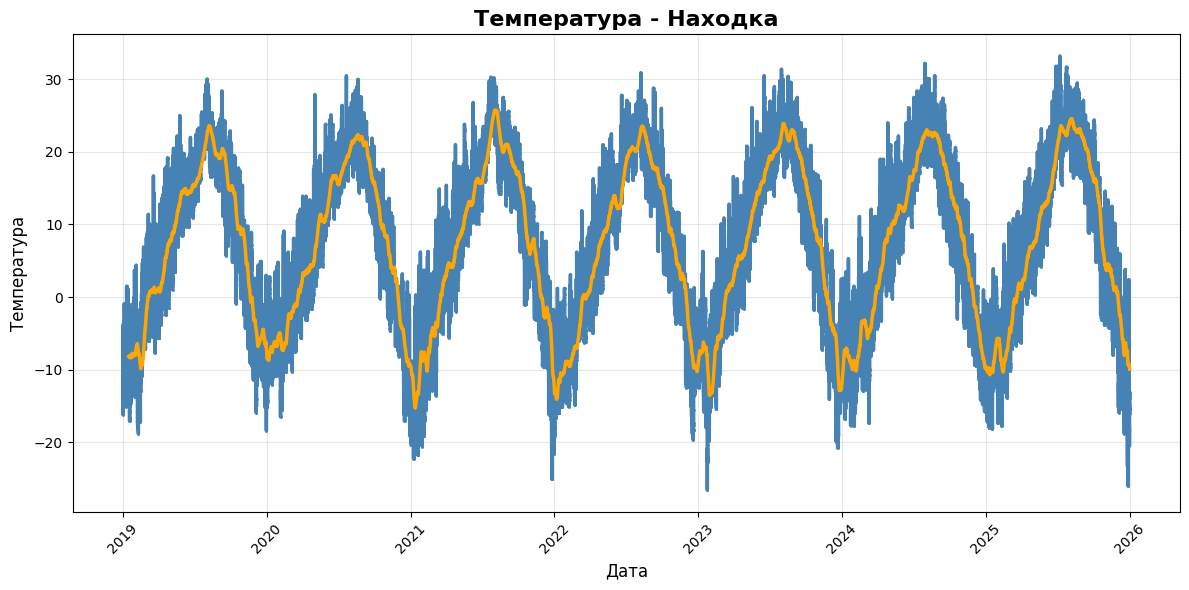

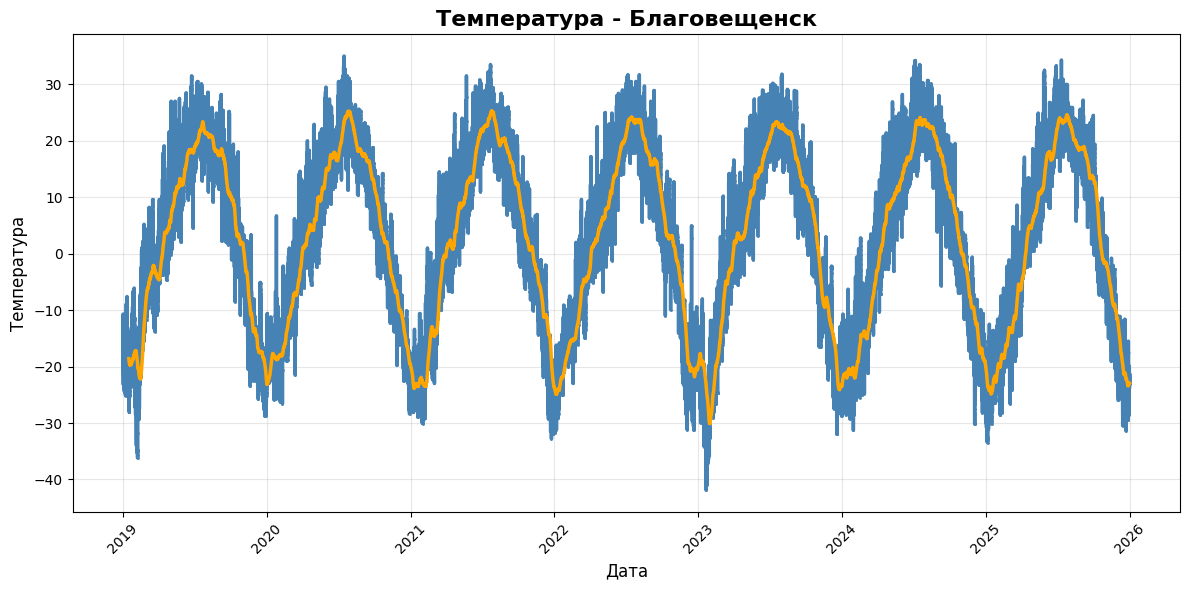

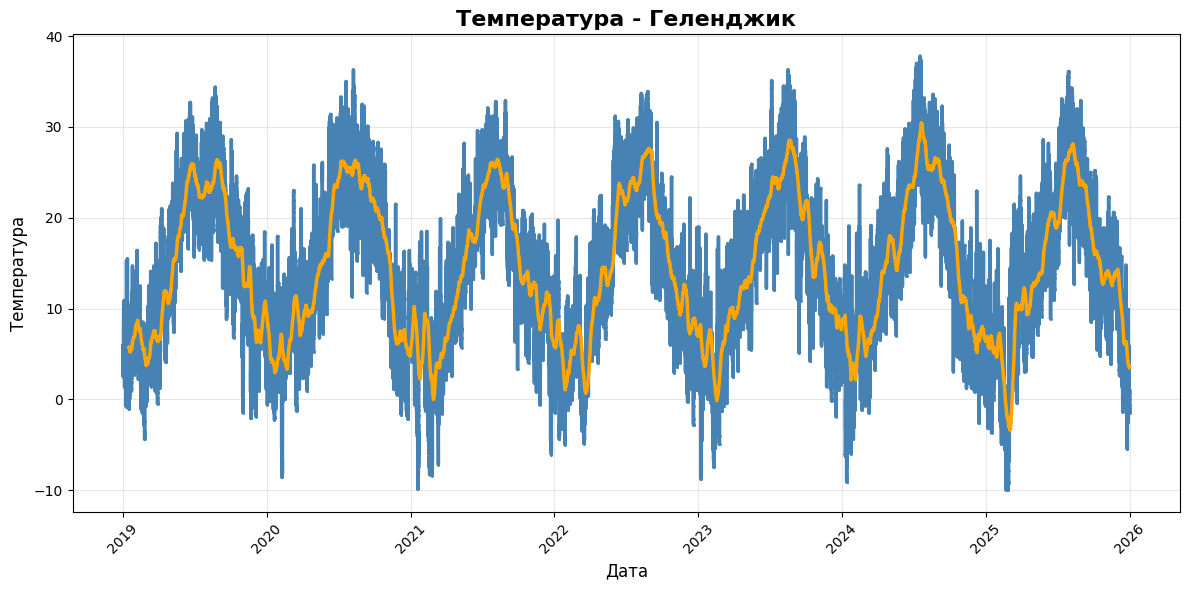

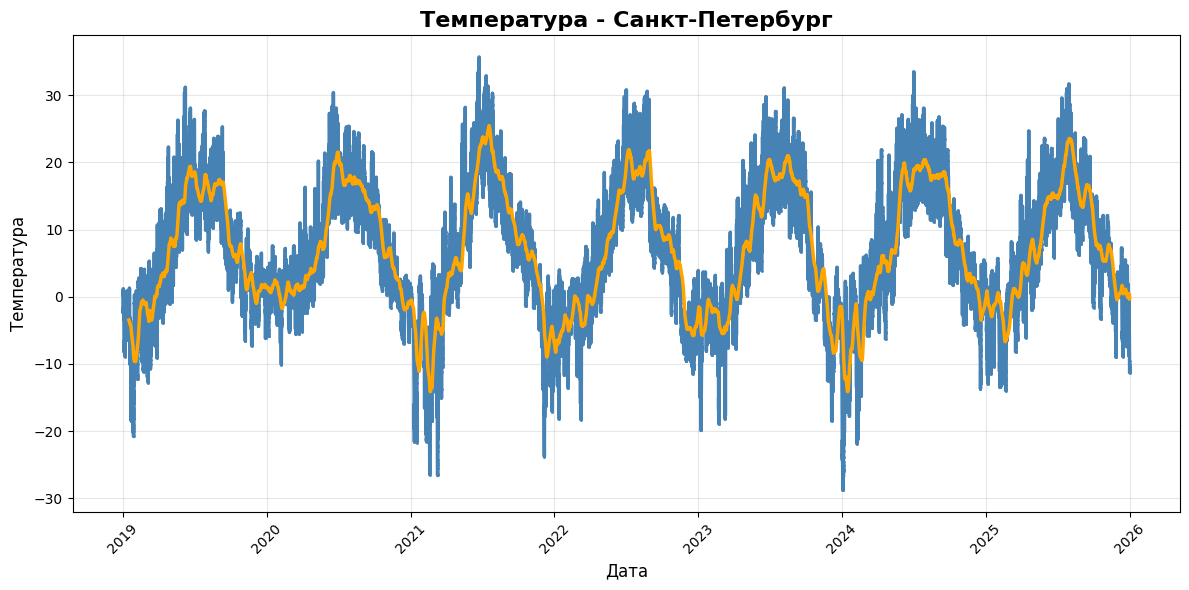

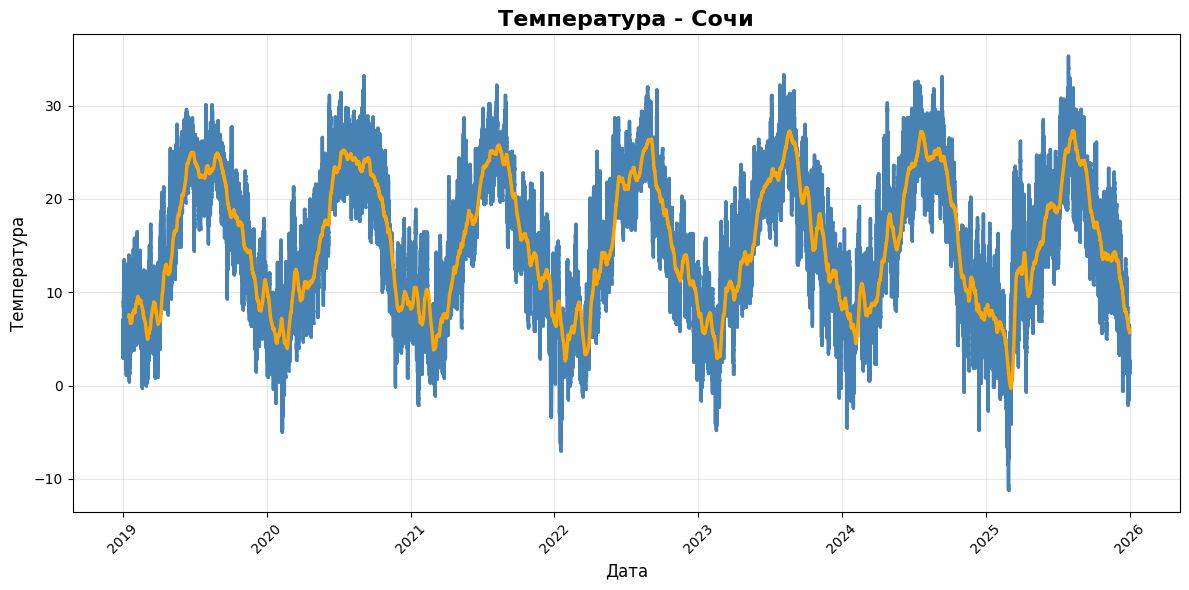

In [50]:
for city, city_df in city_dfs.items():
    plt.figure(figsize=(12, 6))
    plt.plot(city_df['ds'], city_df['temperature_2m'], linestyle='-', linewidth=2.5,  marker='.', markersize=2, color='steelblue')
    plt.plot(city_df['ds'], city_df['temperature_2m'].rolling(window=365).mean(), linewidth=2.5, color='orange', label='Скользящее среднее за 12 месяцев')
    plt.title(f'Температура - {city}', fontsize=16, fontweight='bold')
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Температура', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

На каждом графике видно годовую сезонность.

### Тест Дики-Фуллера
Проведем его, чтобы понять, стационарен ли ряд:

In [51]:
from statsmodels.tsa.stattools import adfuller

for city, city_df in city_dfs.items():
    result = adfuller(city_df["temperature_2m"].dropna())
    print(city)
    print(f"p-value: {result[1]:.10f}")

/tmp/ipykernel_517/3199726493.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(city_df["temperature_2m"].dropna())


Москва
p-value: 0.0000000516


/tmp/ipykernel_517/3199726493.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(city_df["temperature_2m"].dropna())


Находка
p-value: 0.0000290977


/tmp/ipykernel_517/3199726493.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(city_df["temperature_2m"].dropna())


...

/tmp/ipykernel_517/3199726493.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(city_df["temperature_2m"].dropna())


Геленджик
p-value: 0.0000000002


/tmp/ipykernel_517/3199726493.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(city_df["temperature_2m"].dropna())


Санкт-Петербург
p-value: 0.0000001324
Сочи
p-value: 0.0000000195


/tmp/ipykernel_517/3199726493.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(city_df["temperature_2m"].dropna())


Видим, что все p-value получились < 0.5, значит ряды стационарны и нет необходимости в их дифференцировании.

### Декомпозиция временного ряда
Сделаем аддитивную декомпозицию. Сначала посмотрим на декомпозицию с периодом 365, т.е. 1 год, но для модифицированного датасета: вместо почасовых данных нам нужны посуточные

/tmp/ipykernel_517/2554717032.py:12: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(


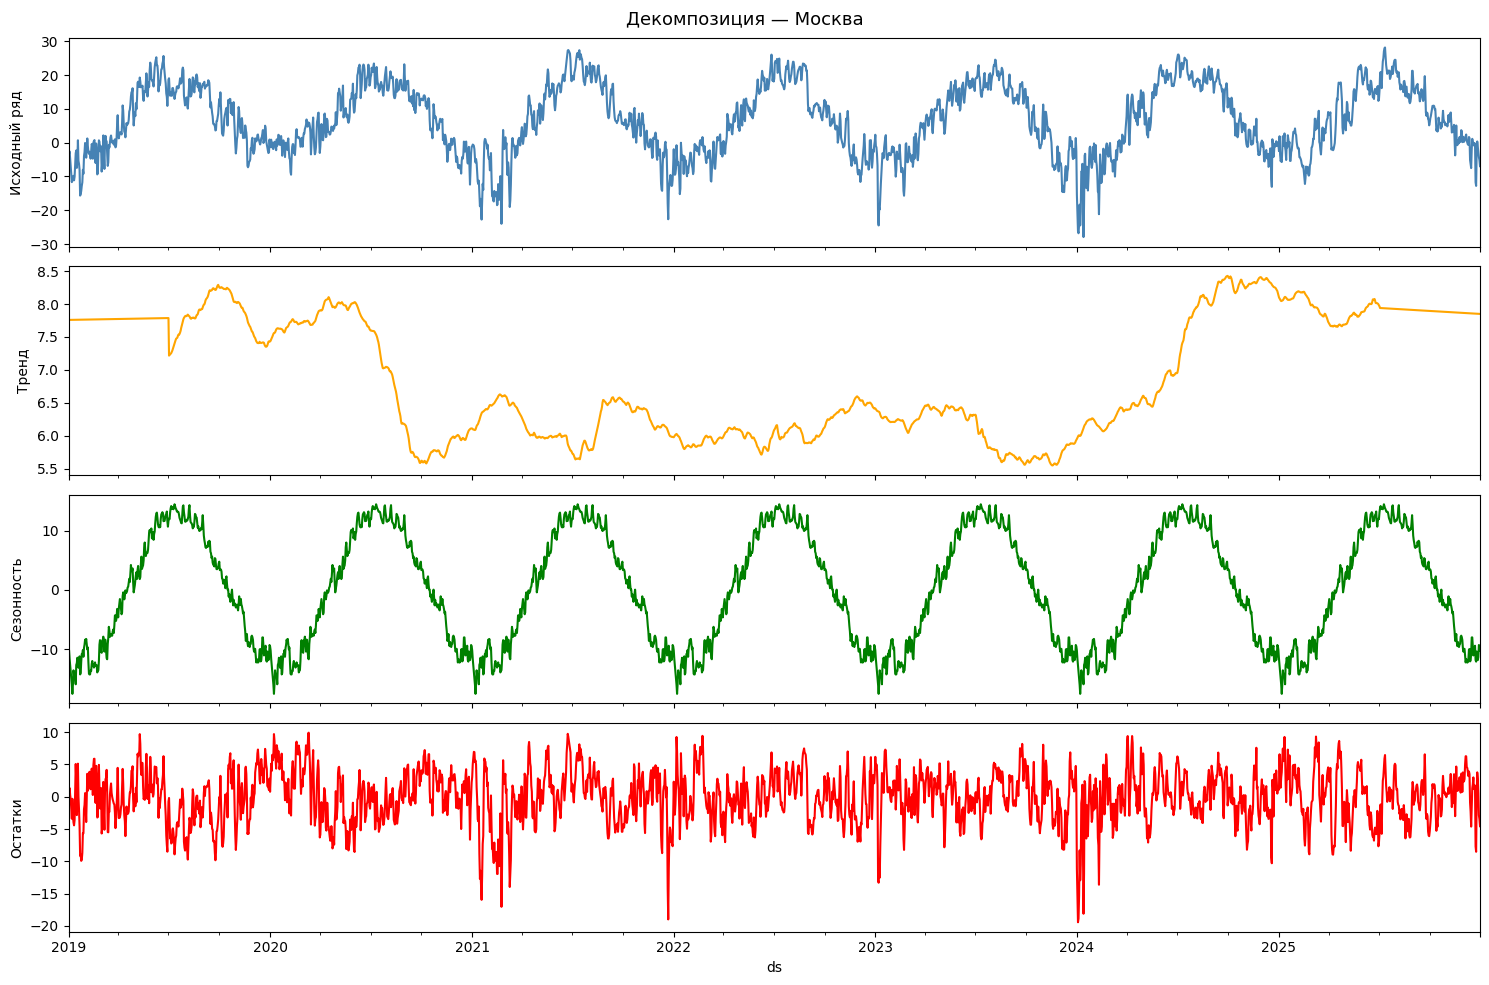

/tmp/ipykernel_517/2554717032.py:12: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(


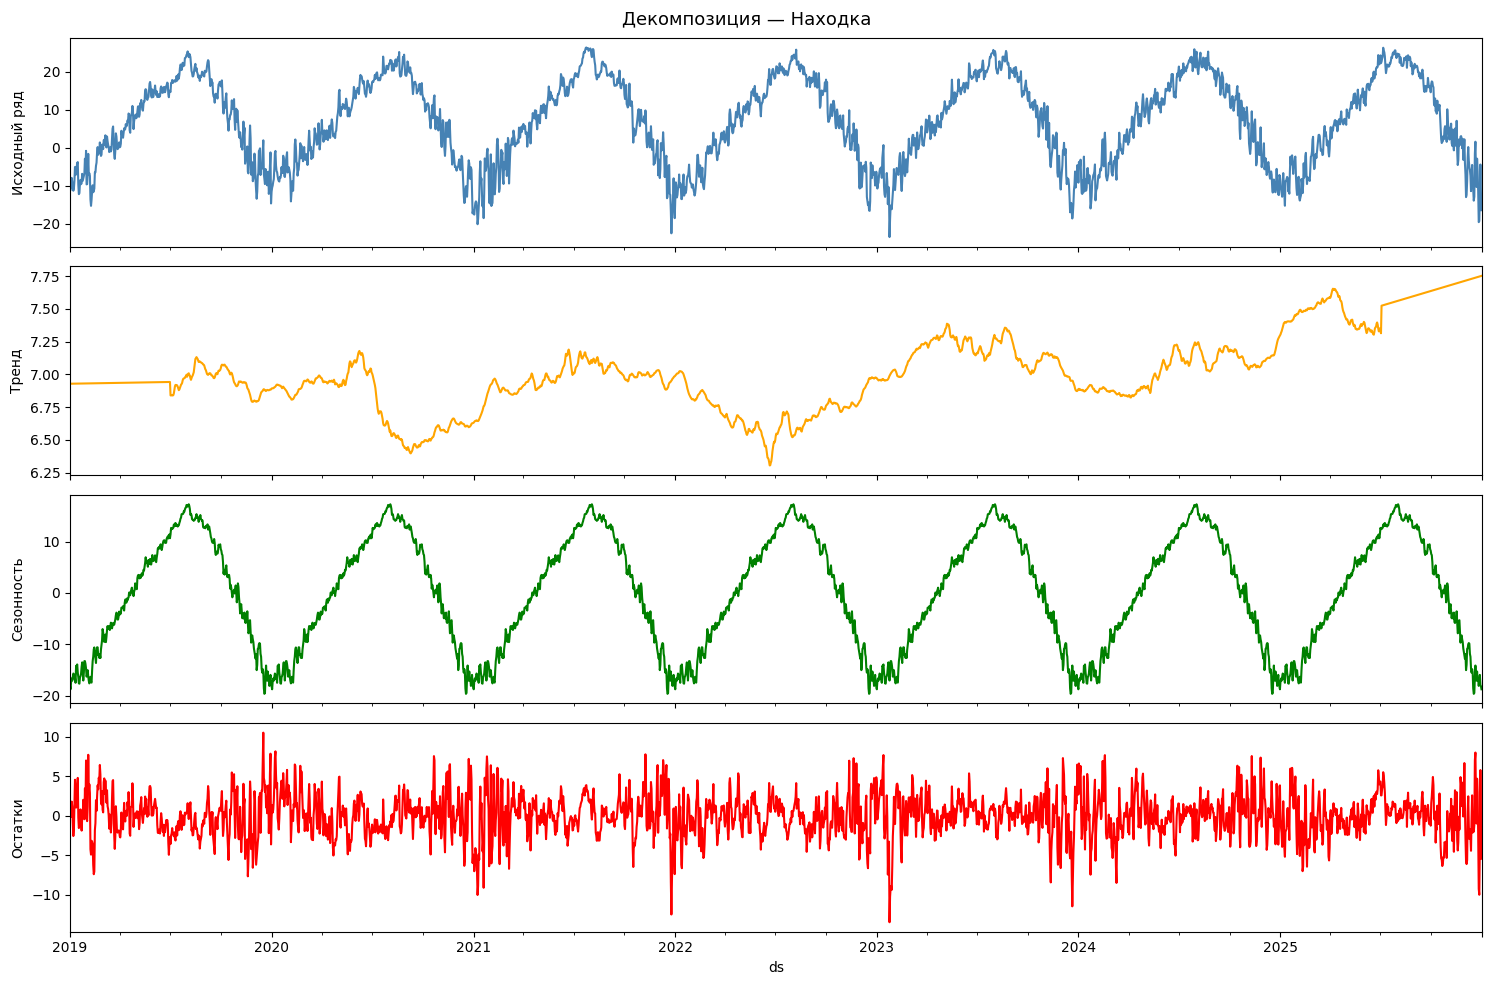

/tmp/ipykernel_517/2554717032.py:12: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(


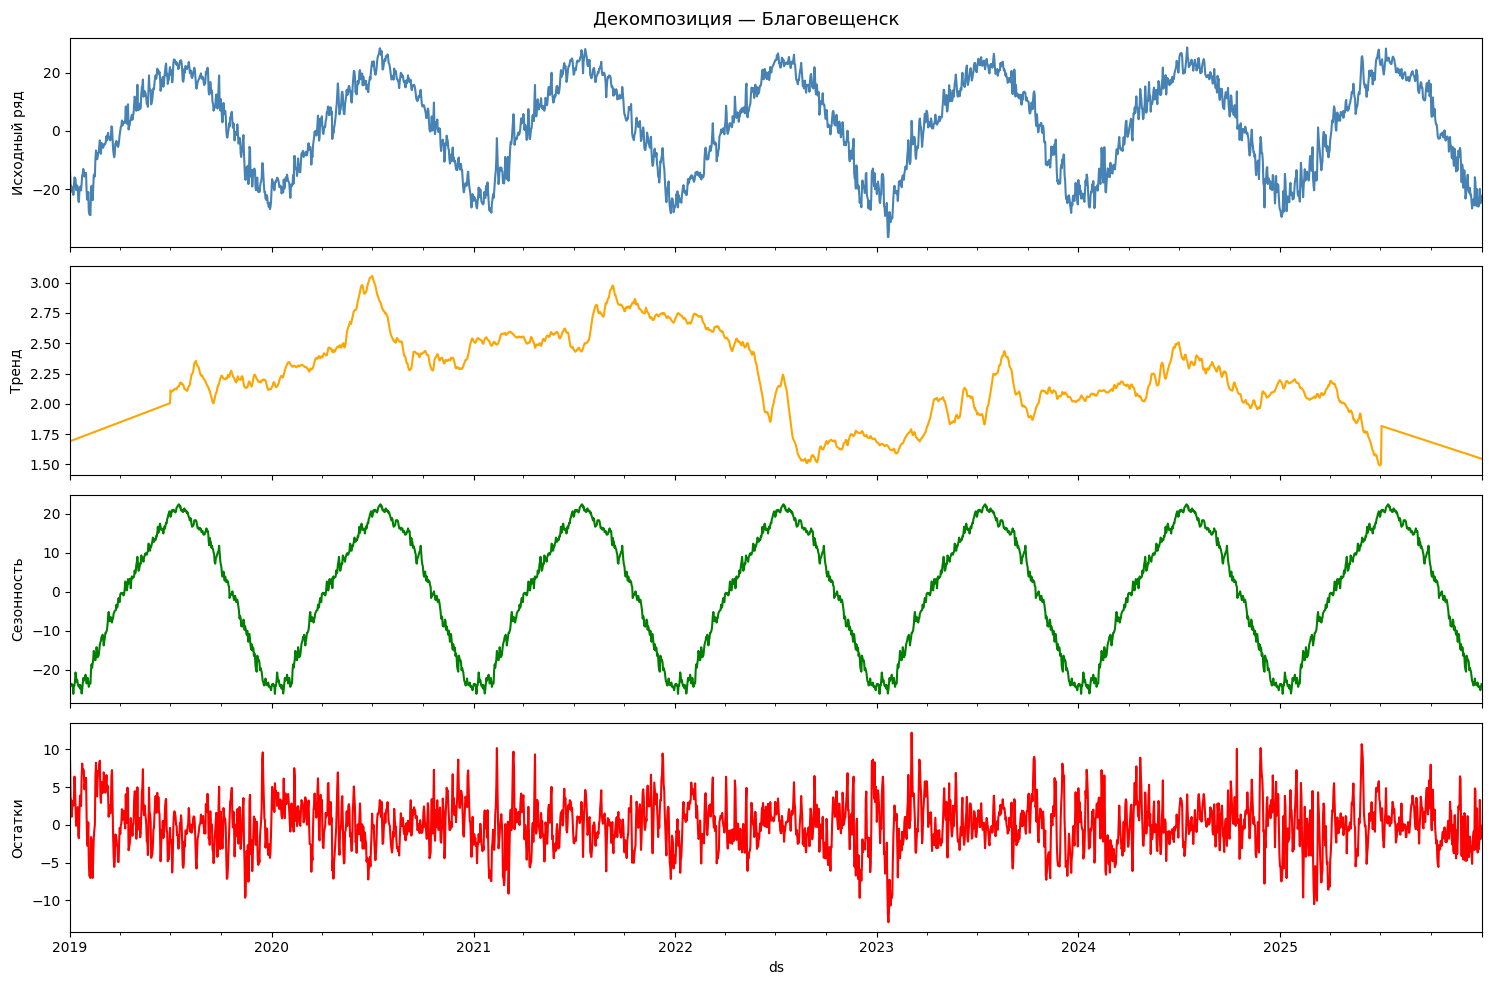

/tmp/ipykernel_517/2554717032.py:12: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(


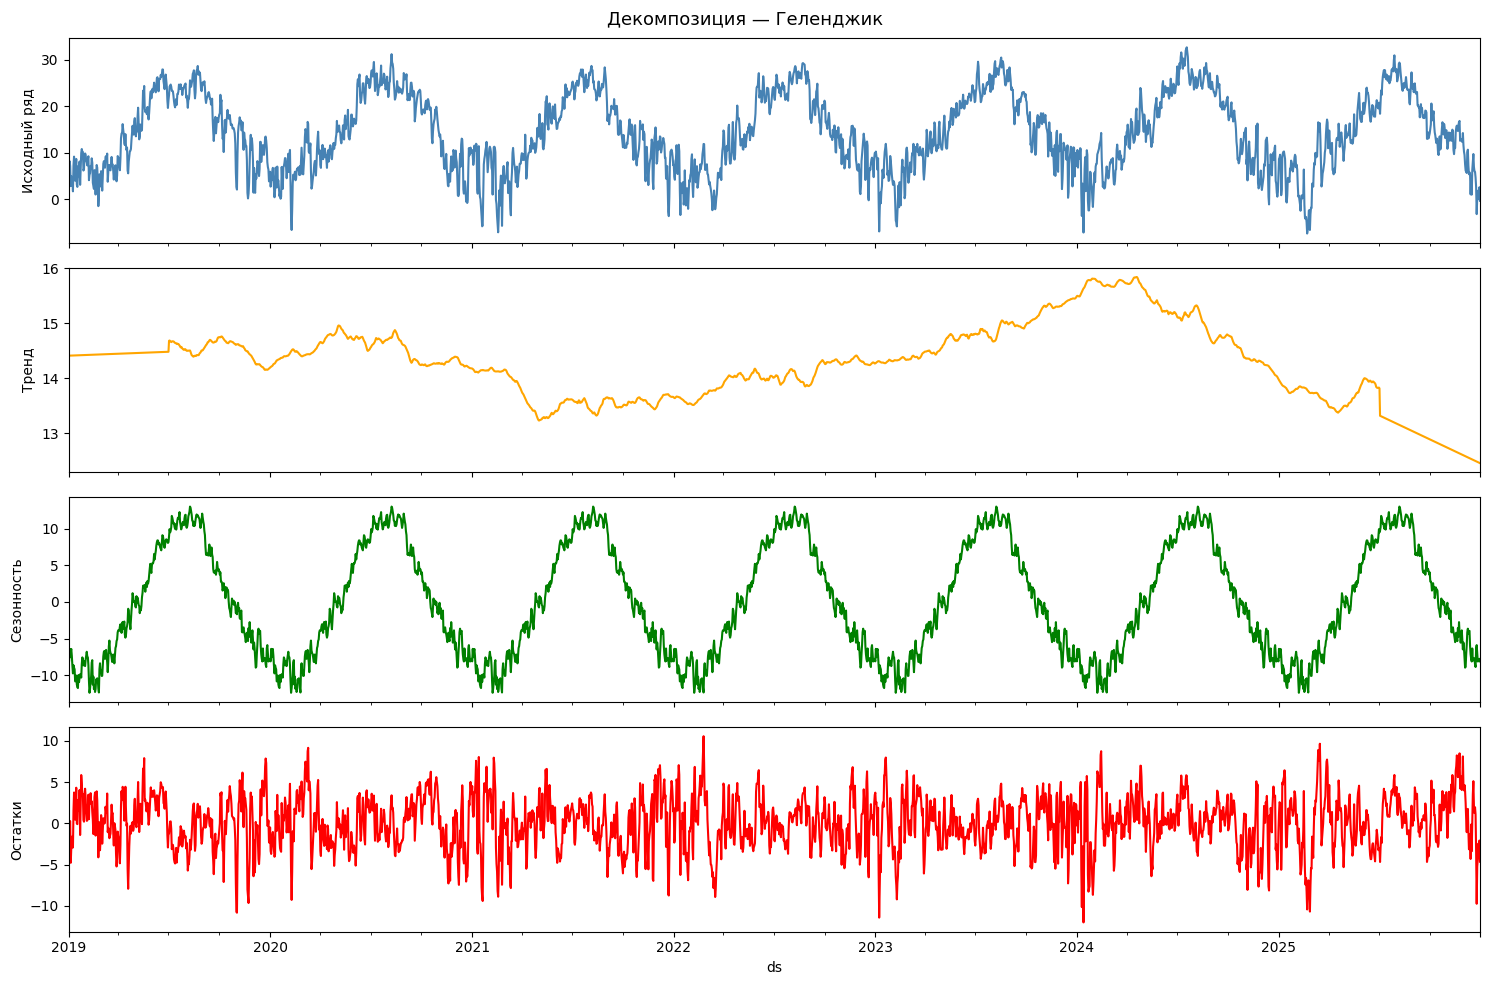

/tmp/ipykernel_517/2554717032.py:12: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(


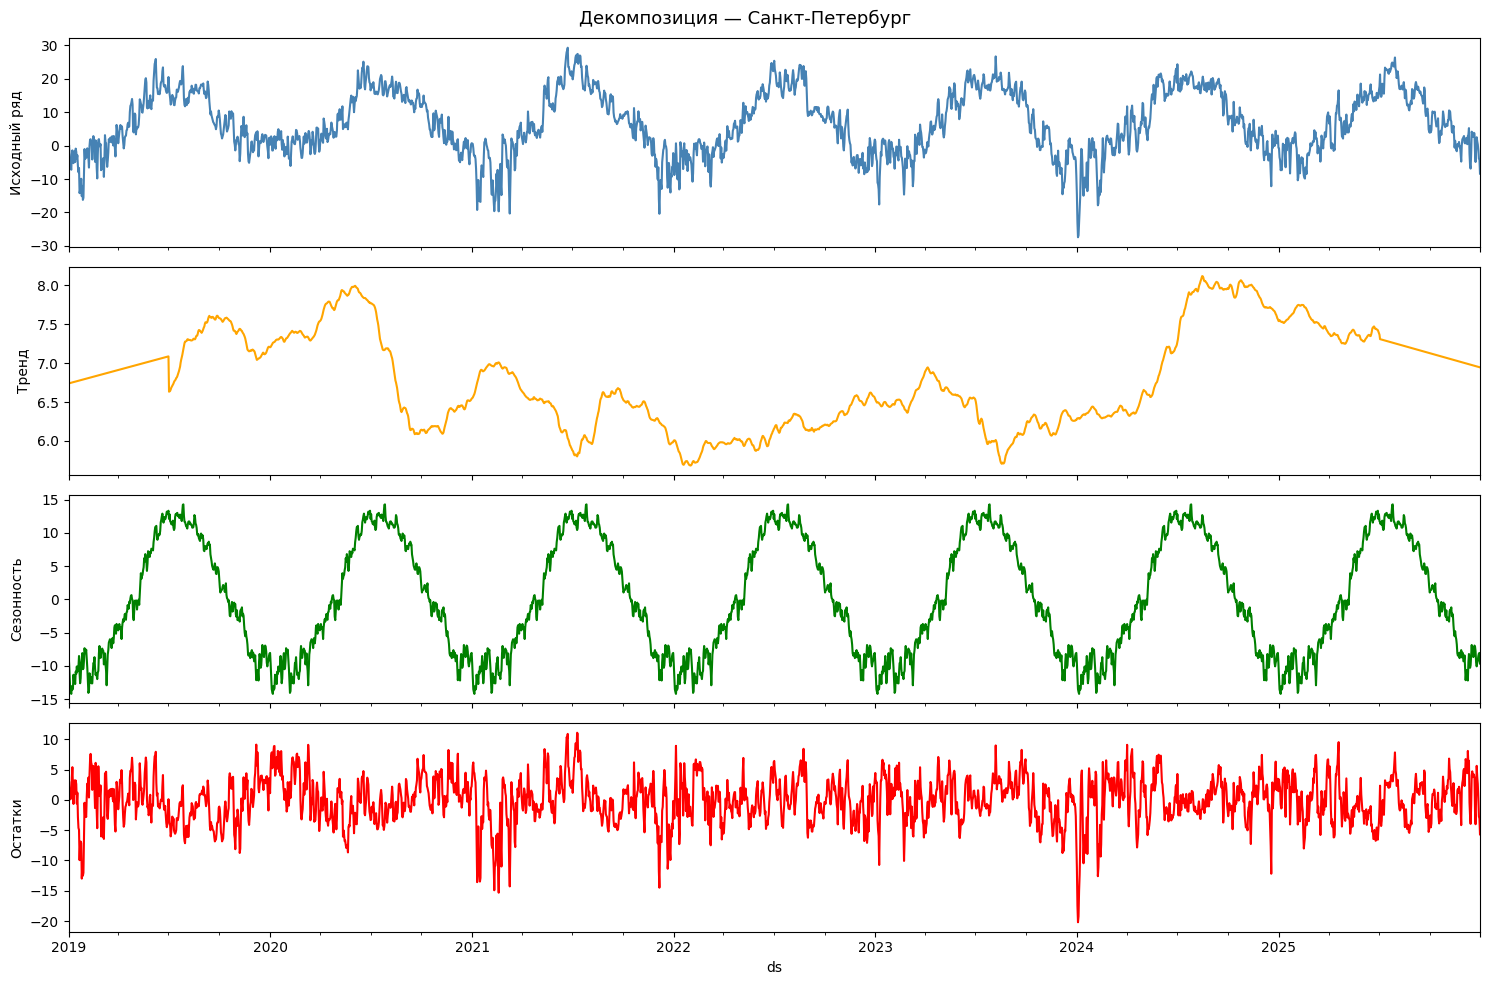

/tmp/ipykernel_517/2554717032.py:12: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(


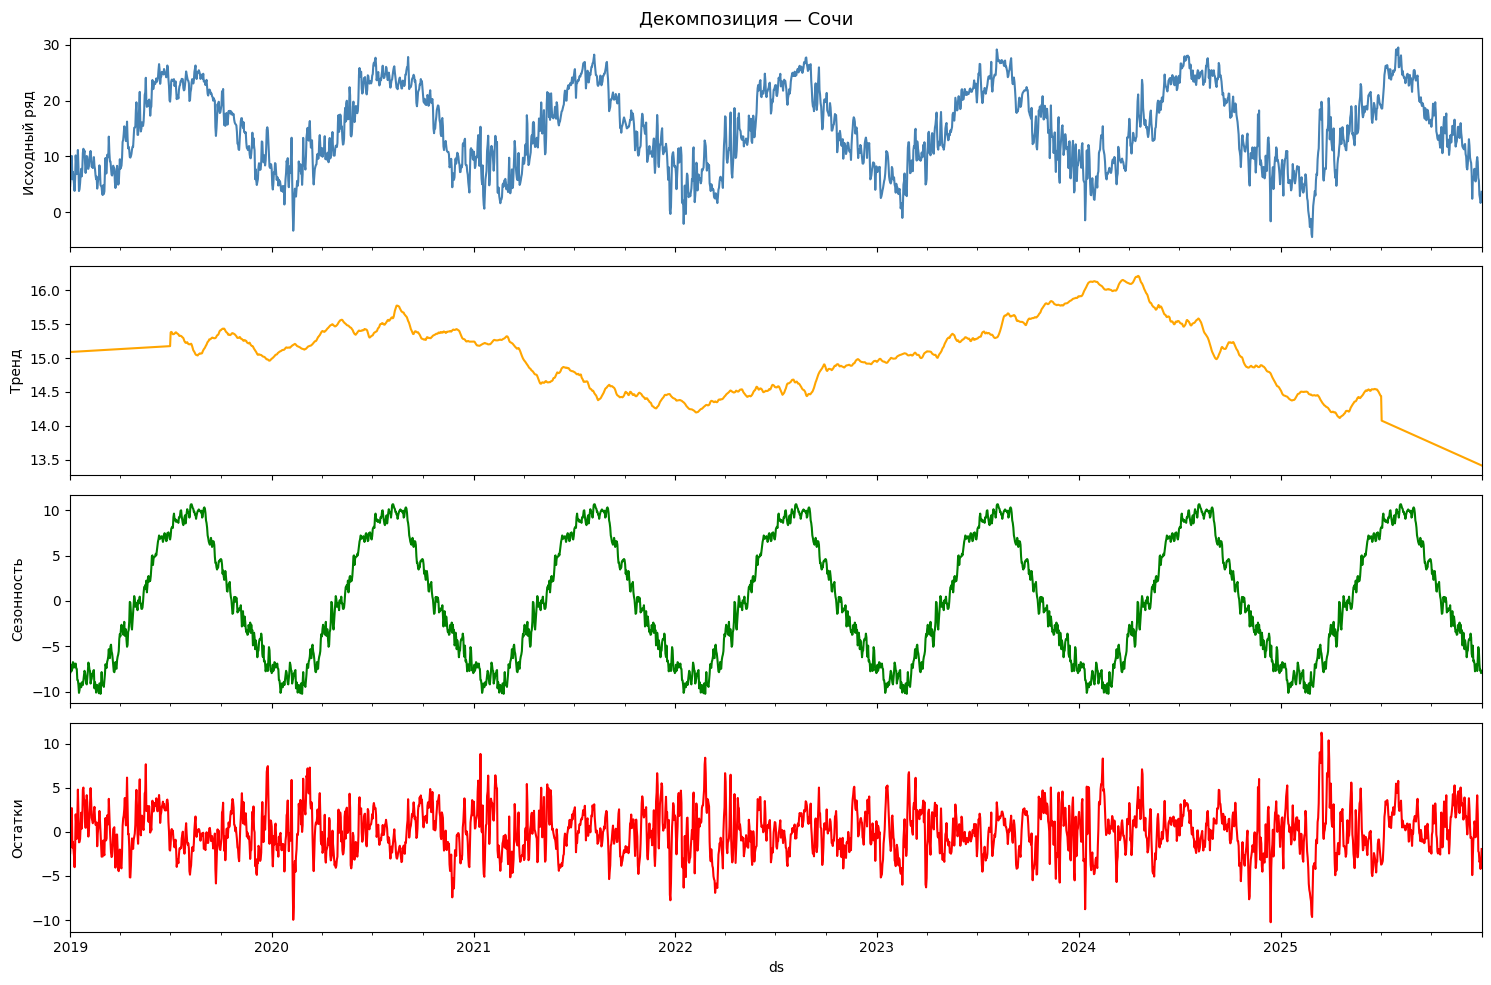

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose

for city_name, df in city_dfs.items():
    # Создаём подневный ряд (среднесуточную температуру)
    daily = (df
             .set_index('ds')['temperature_2m']
             .resample('D')
             .mean()
             .dropna())

    # Декомпозиция
    decomp = seasonal_decompose(
        daily,
        model='additive',
        period=365,
        extrapolate_trend='freq'
    )

    # Визуализация
    fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

    decomp.observed.plot(ax=axes[0], color='steelblue')
    axes[0].set_ylabel('Исходный ряд')

    decomp.trend.plot(ax=axes[1], color='orange')
    axes[1].set_ylabel('Тренд')

    decomp.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Сезонность')

    decomp.resid.plot(ax=axes[3], color='red')
    axes[3].set_ylabel('Остатки')

    plt.suptitle(f'Декомпозиция — {city_name}',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

Четко видим сезонность, достаточно стабильный тренд и что остатки - случайный шум

Кроме годовой сезонности есть и суточная, т.е. c периодом 24 (в почасовом датасете). Посмотрим и на такую декомпозицию, но возьмем лишь последние 30 дней, чтобы график вообще был различим.

Москва


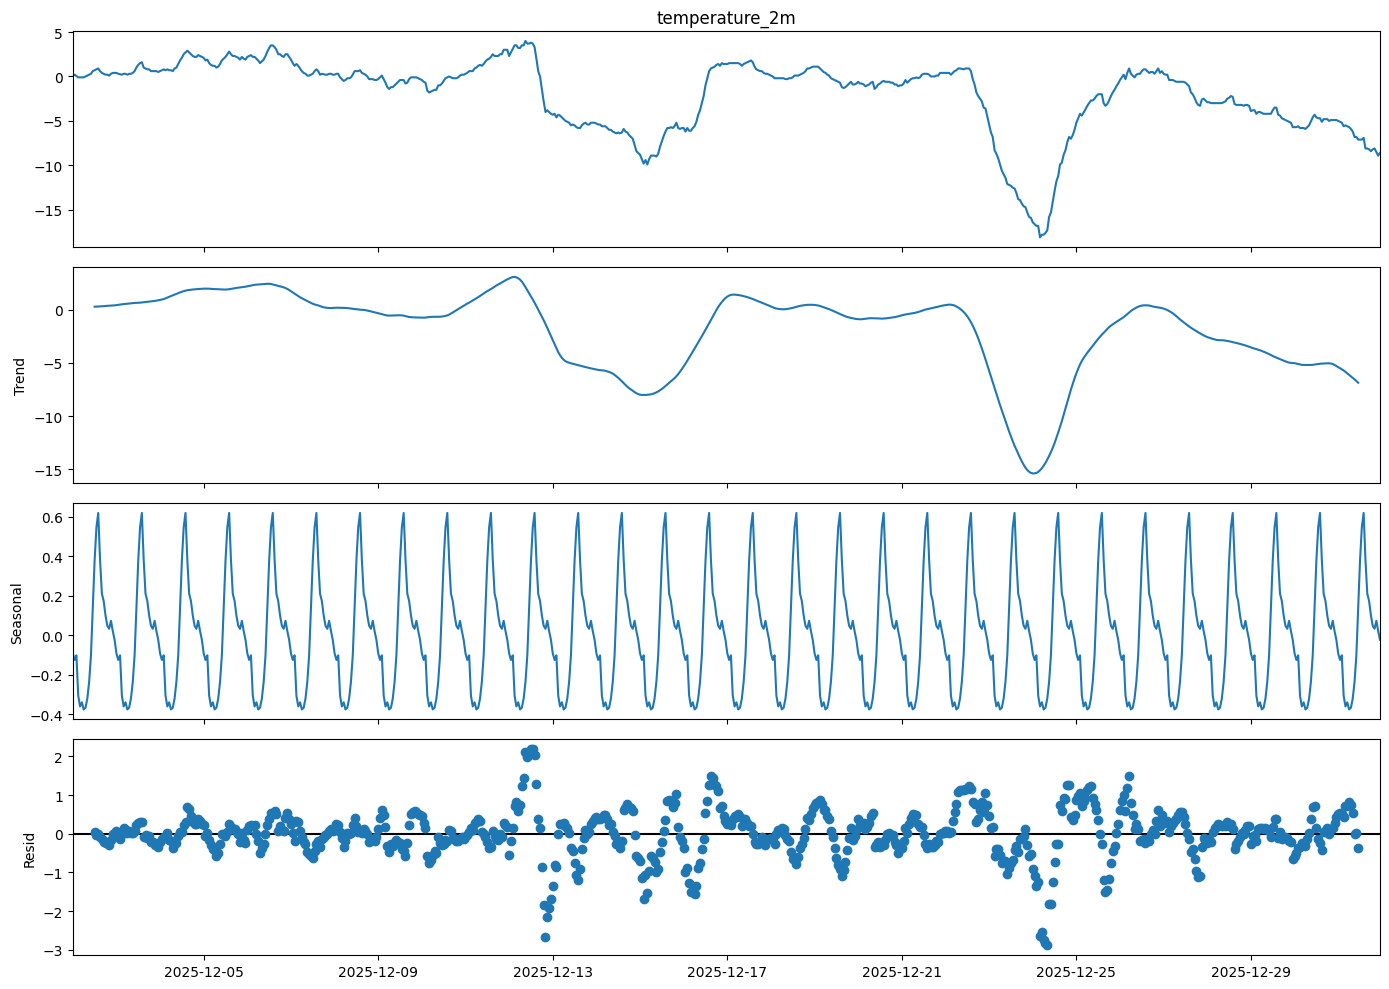

Находка


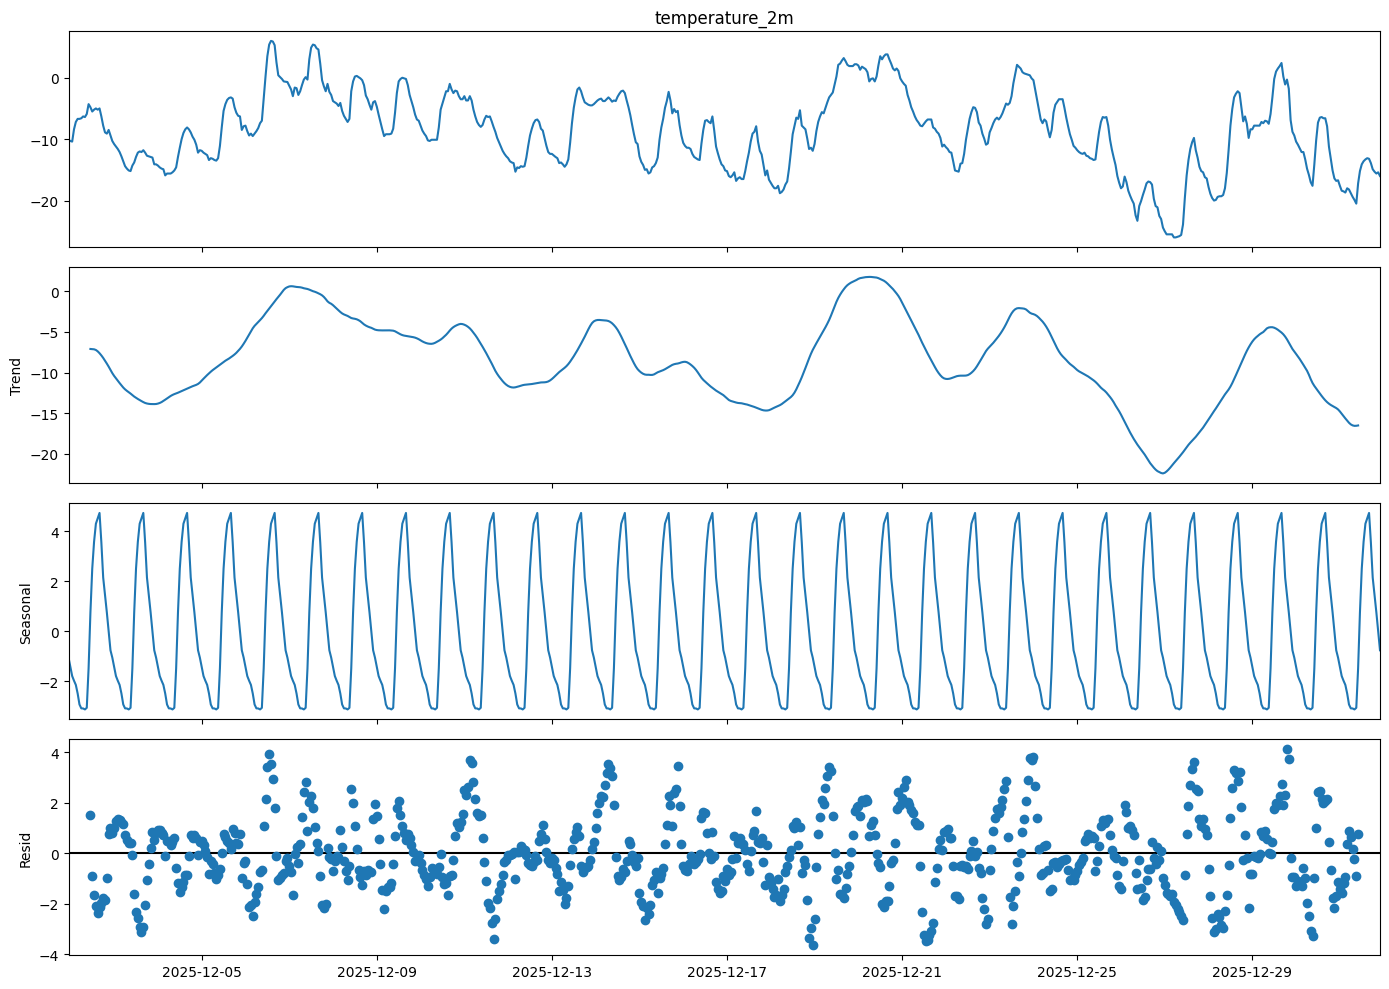

Благовещенск


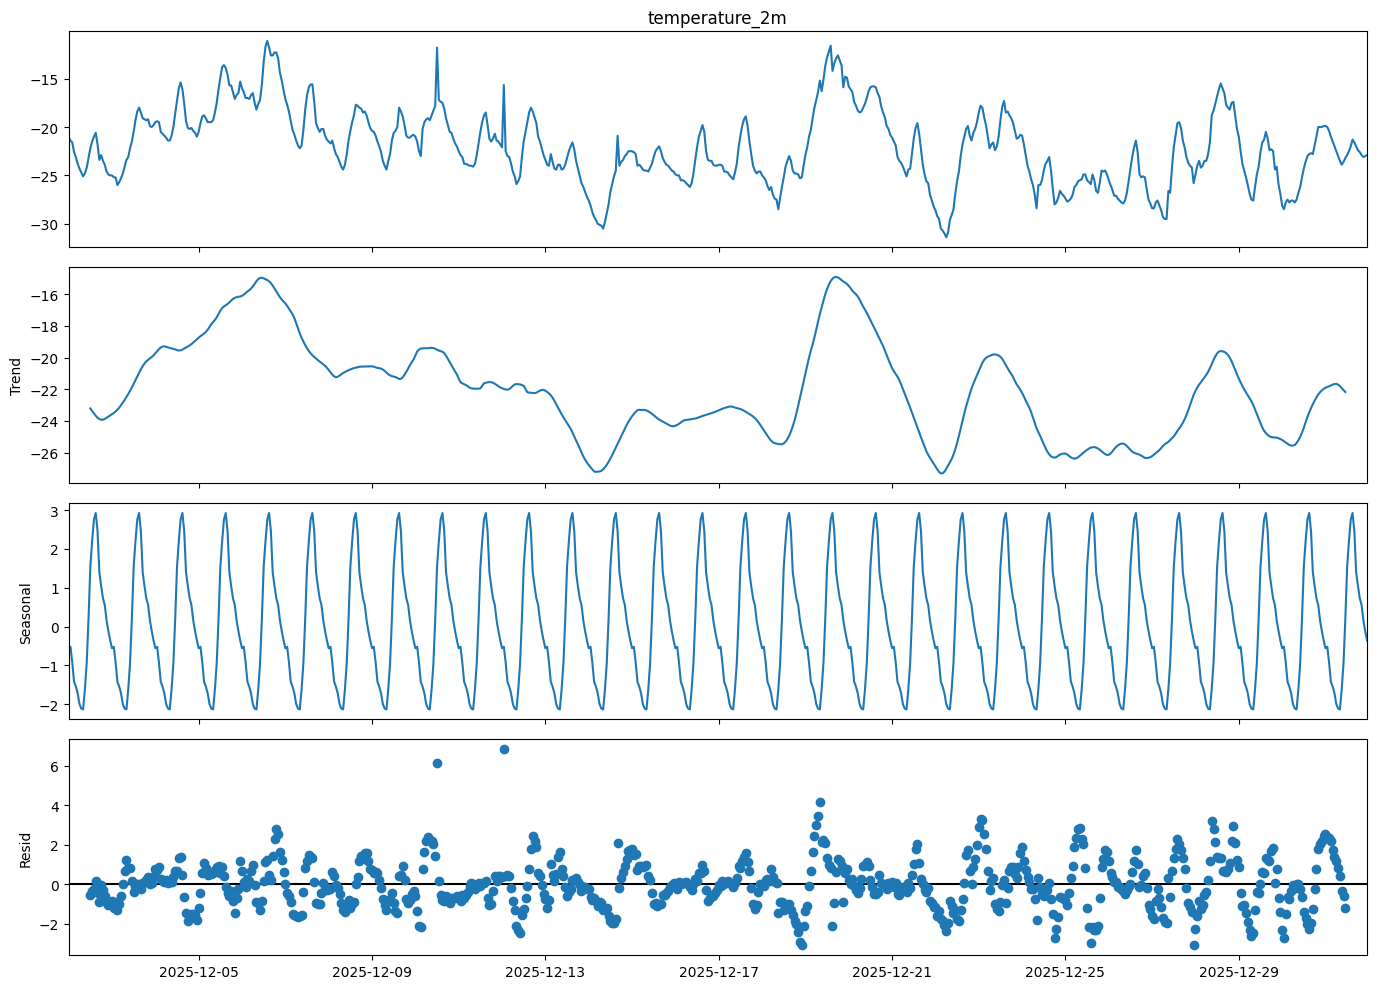

Геленджик


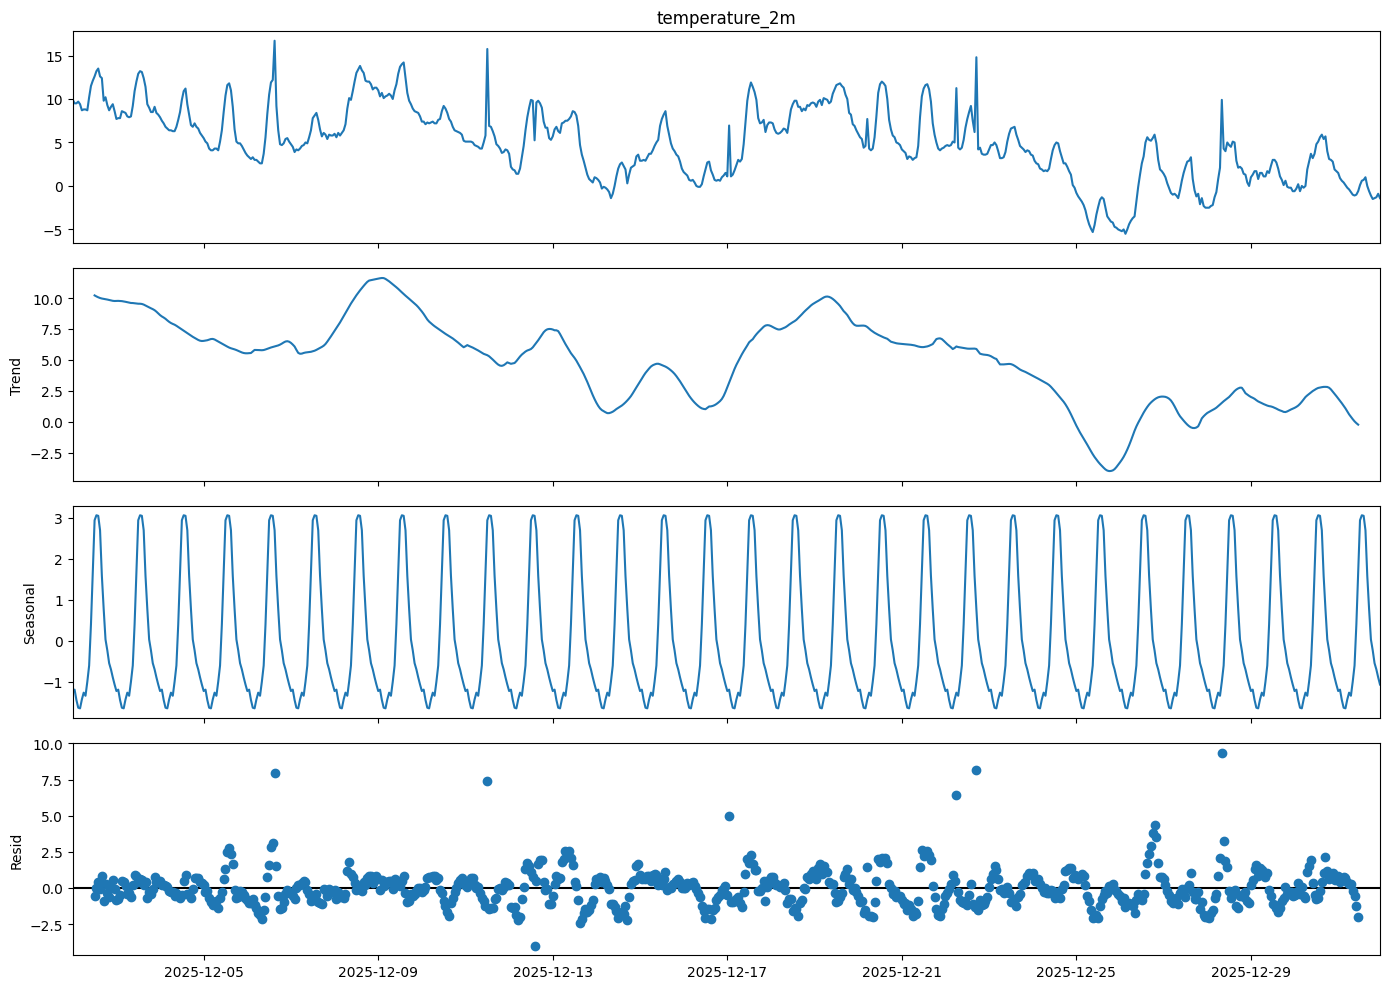

Санкт-Петербург


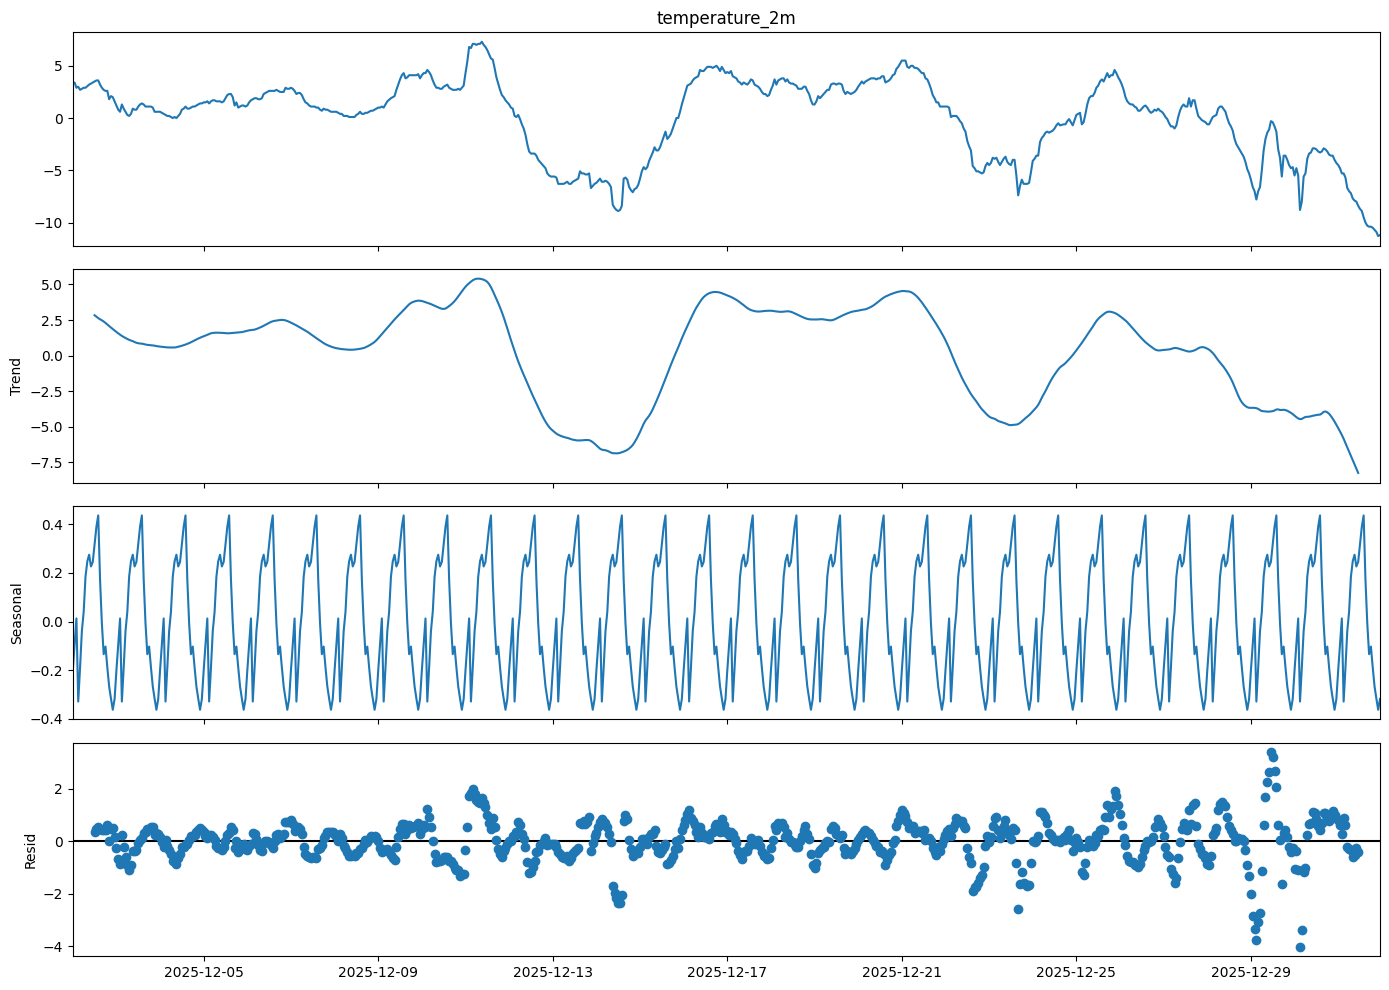

Сочи


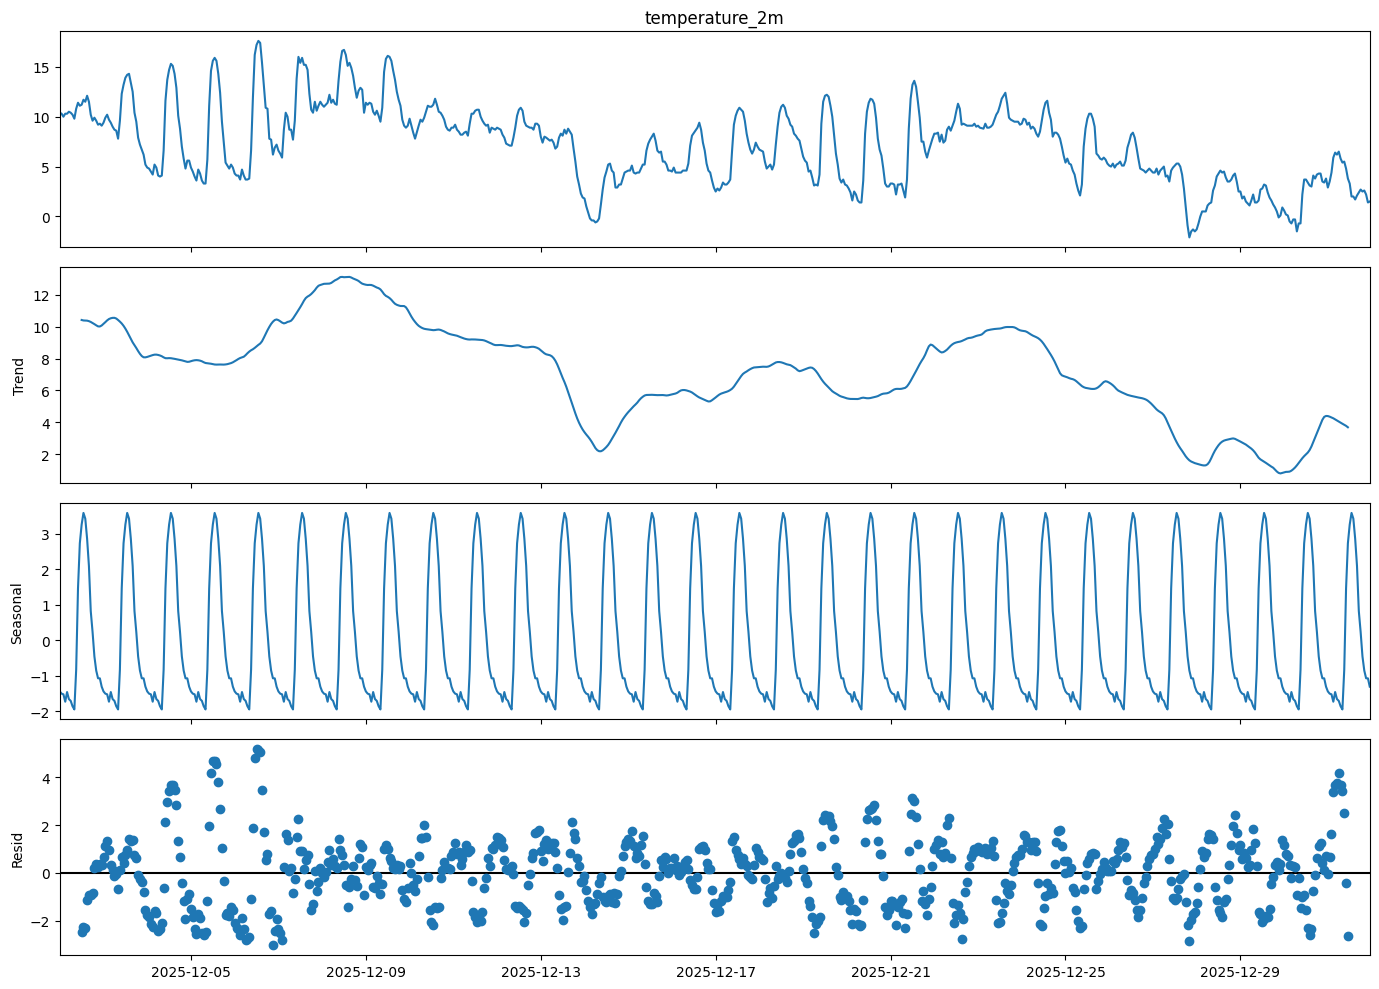

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose

for city, city_df in city_dfs.items():
    city_df = city_df.set_index("ds")
    decomposition = seasonal_decompose(city_df["temperature_2m"].tail(24*30), model="additive", period=24)
    plt.rcParams["figure.figsize"] = (14, 10)
    fig = decomposition.plot()
    print(city)
    plt.show()

### Фурье анализ
У нас стационарные ряды, поэтому моежм применить FFT и увидеть, какие ещё скрытые периодичности есть в нашем ряде

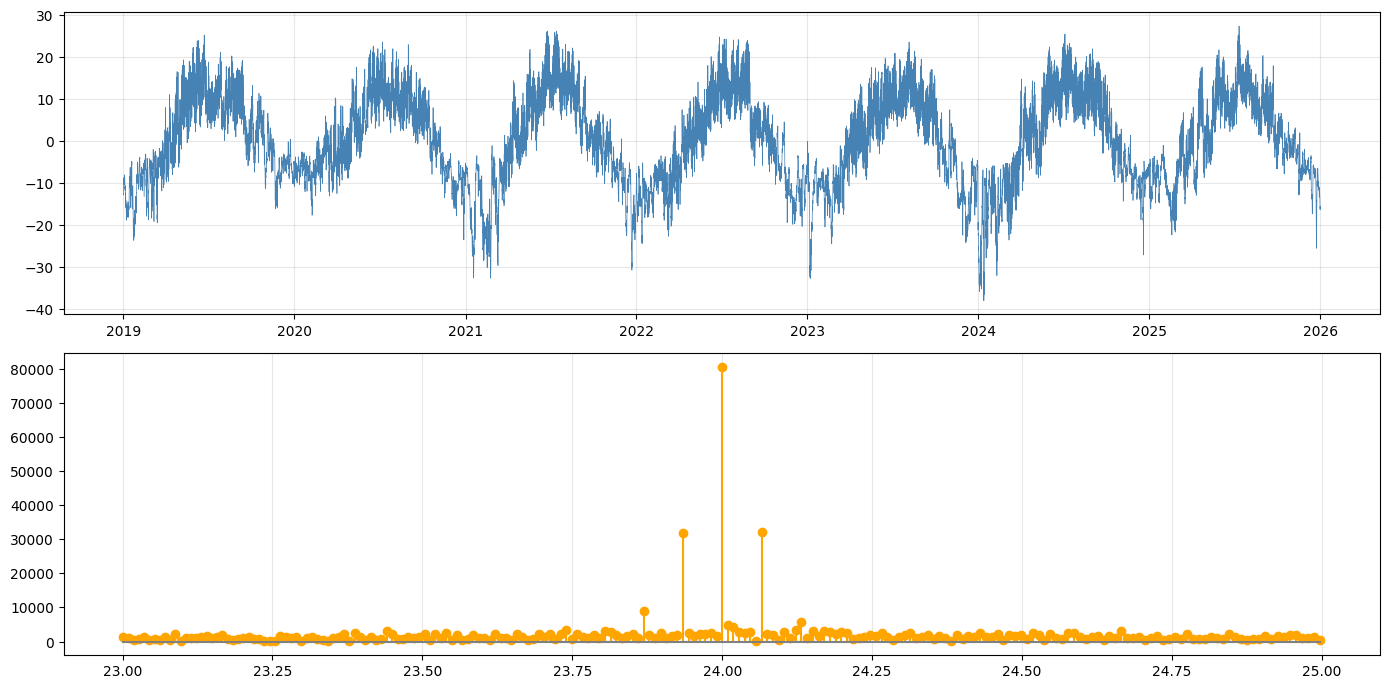

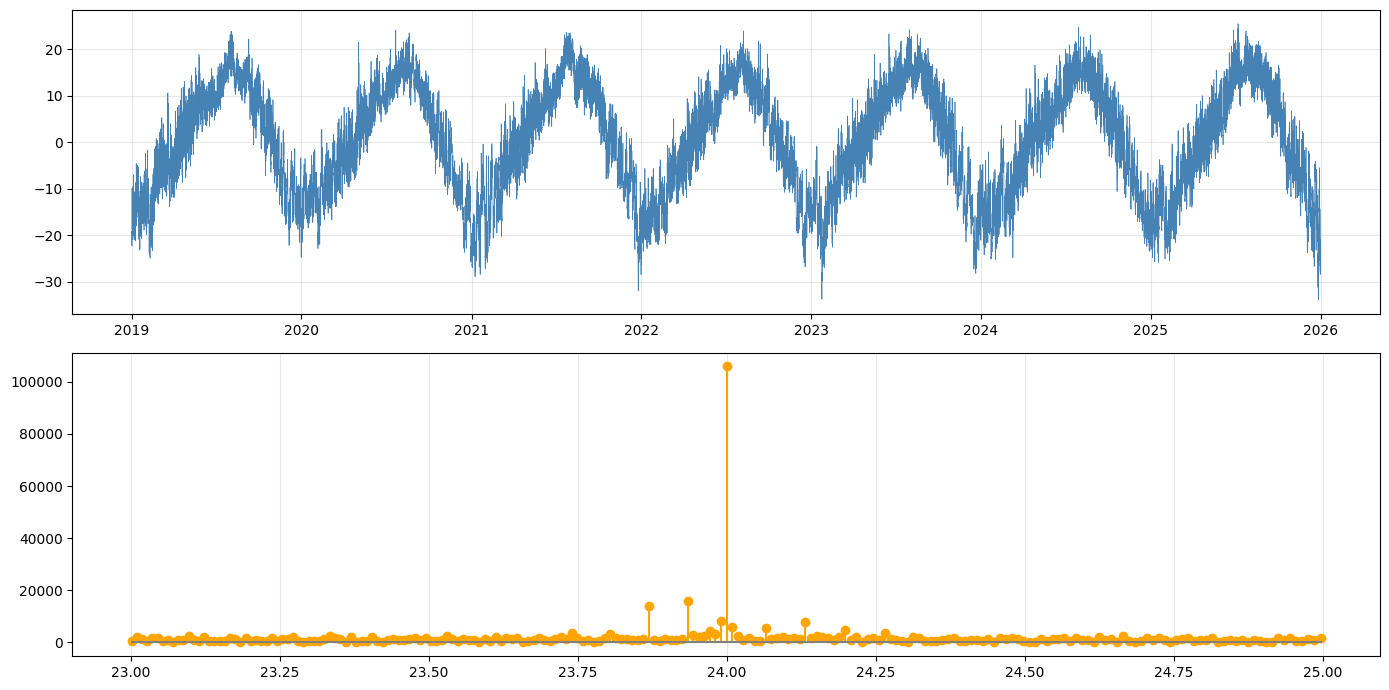

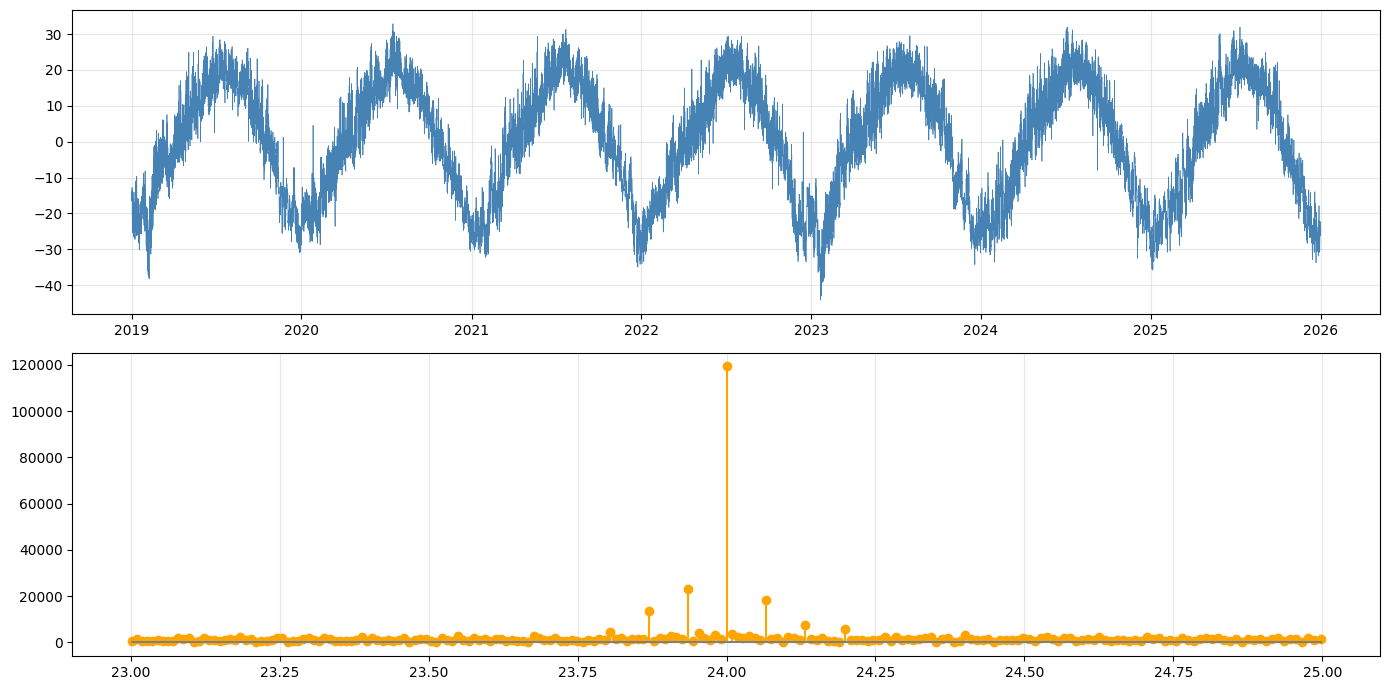

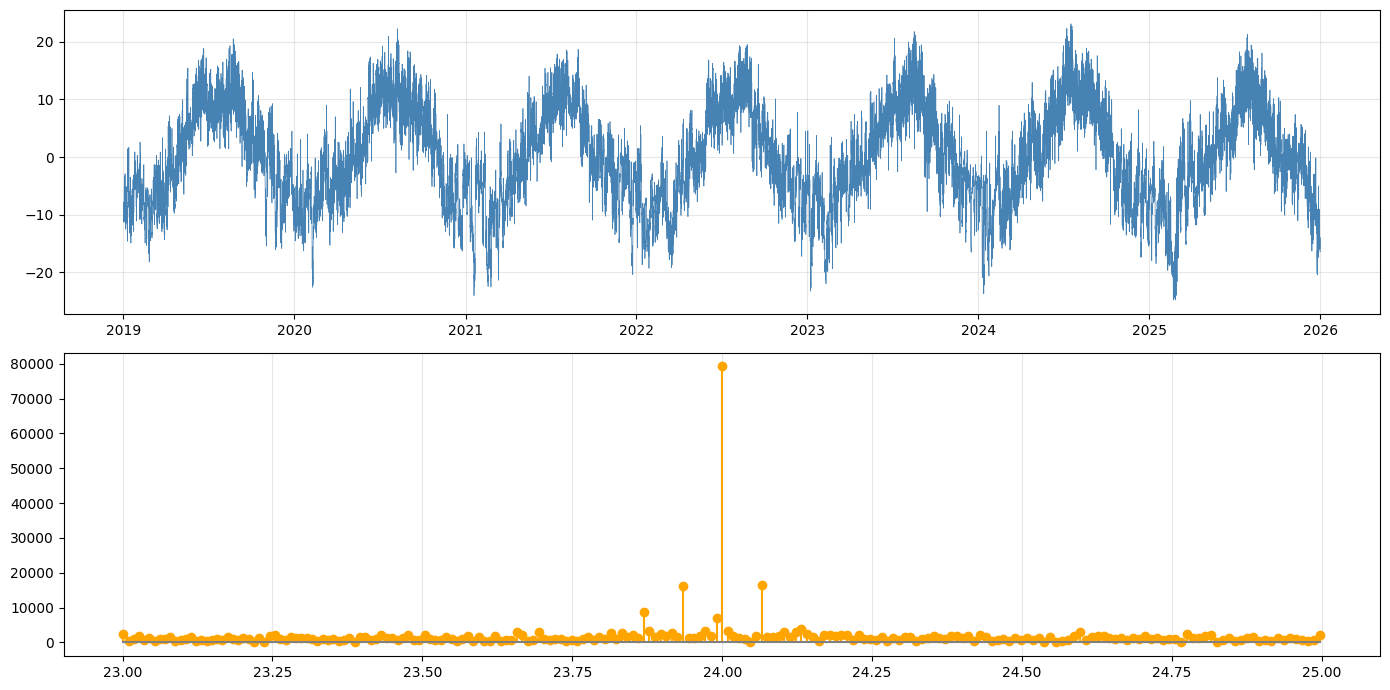

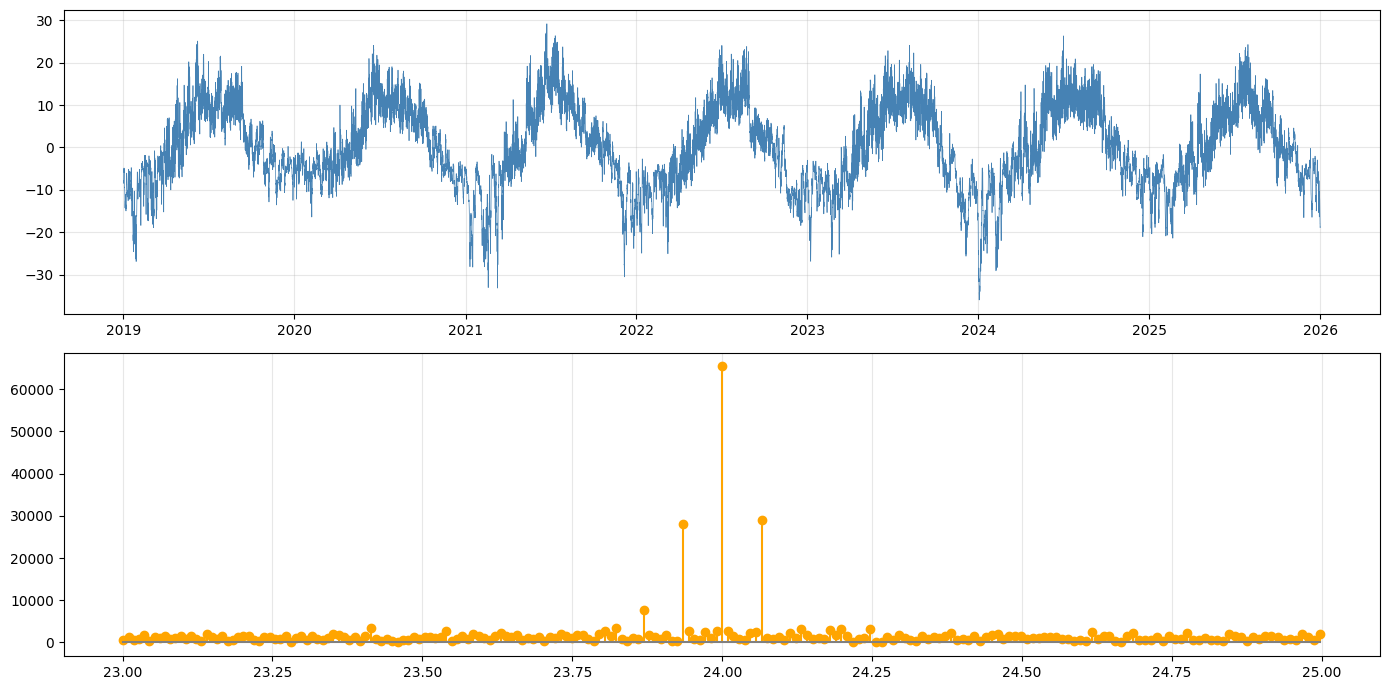

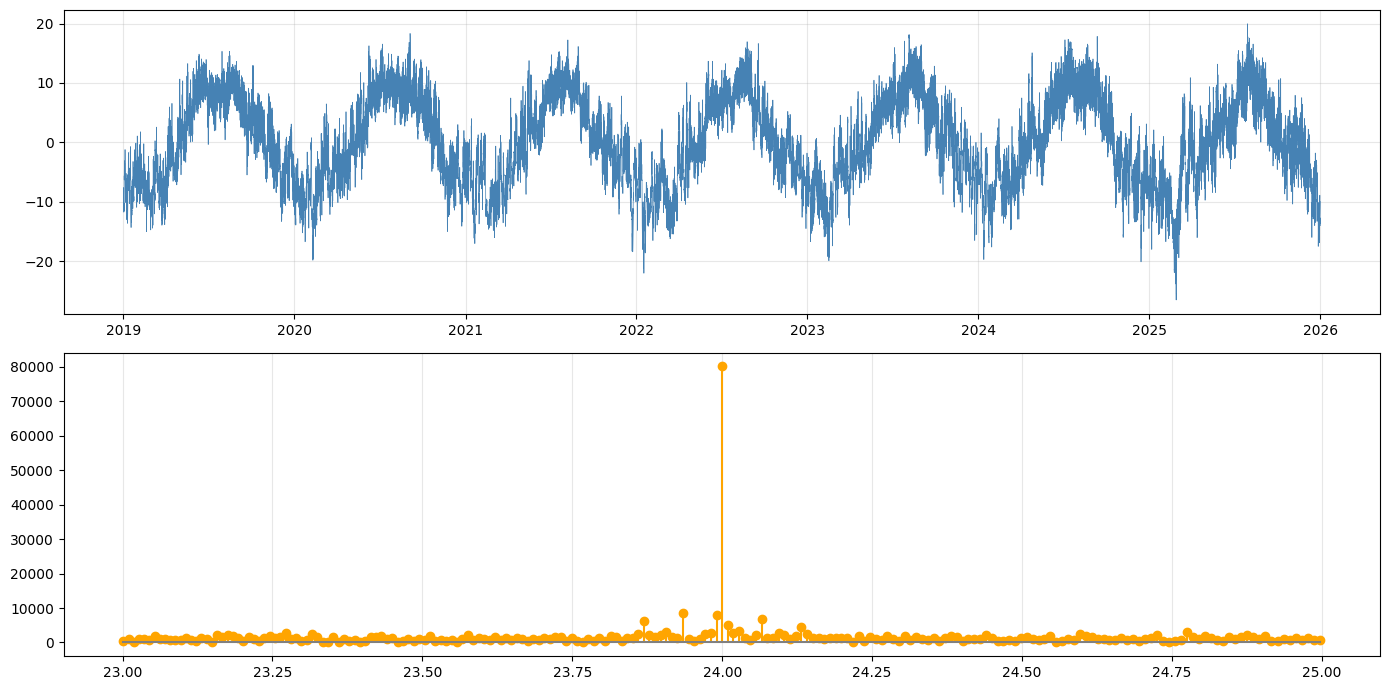

In [54]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.signal import detrend

for city, city_df in city_dfs.items():
    city_df = city_df.set_index("ds")
    temp = detrend(city_df["temperature_2m"])
    dt = 1
    n = len(temp)
    fft_vals = fft(temp)
    freqs = fftfreq(n, dt)
    power = np.abs(fft_vals[:n//2])
    freqs_pos = freqs[:n//2]
    periods = 1 / freqs_pos[freqs_pos > 0]
    power_pos = power[freqs_pos > 0]
    fig, axs = plt.subplots(2, 1, figsize=(14, 7))

    axs[0].plot(city_df["temperature_2m"].index, temp, color='steelblue', linewidth=0.5)
    axs[0].grid(True, alpha=0.3)

    mask = (periods >= 23) & (periods <= 25)
    axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
    axs[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

Можем пронаблюдать суточную сезонность.

## Извлечение полезных признаков

Кодируем даты с помощью синусов и косинусов, чтобы модель видела цикличность, берем признаки, связанные с важными лагами и метеорологическими параметрами:

In [55]:
WINDOW = 7 * 24
HORIZONS = list(range(24, 169, 24))

def make_features(city_dfs: dict, window=WINDOW, horizons=HORIZONS):
    records = []

    for city_name, df in city_dfs.items():
        grp = df.copy()
        if isinstance(grp.index, pd.DatetimeIndex) or 'ds' not in grp.columns:
            if 'ds' in grp.columns:
                grp = grp.reset_index(drop=True)
            else:
                print(f"Ошибка: в датафрейме {city_name} нет колонки 'ds'")
                continue

        grp = grp.sort_values('ds').reset_index(drop=True)

        T = grp['temperature_2m'].values
        HUM = grp['relative_humidity_2m'].values if 'relative_humidity_2m' in grp.columns else np.zeros(len(grp))
        PRESS = grp['surface_pressure'].values if 'surface_pressure' in grp.columns else np.zeros(len(grp))
        WIND = grp['wind_speed_10m'].values if 'wind_speed_10m' in grp.columns else np.zeros(len(grp))
        TS = grp['ds'].values

        for i in range(window, len(T) - max(horizons)):
            w = T[i - window:i]
            w24 = T[i - 24:i]
            ts = pd.Timestamp(TS[i])

            row = {
                'lag_1h': T[i - 1],
                'lag_2h': T[i - 2],
                'lag_3h': T[i - 3],
                'lag_6h': T[i - 6],
                'lag_12h': T[i - 12],
                'lag_24h': T[i - 24],
                'lag_48h': T[i - 48],
                'lag_72h': T[i - 72],
                'lag_96h': T[i - 96],
                'lag_120h': T[i - 120],
                'lag_144h': T[i - 144],
                'lag_168h': T[i - 168],

                'roll_mean_24h': w24.mean(),
                'roll_std_24h': w24.std(),
                'roll_mean_7d': w.mean(),
                'roll_std_7d': w.std(),
                'roll_min_7d': w.min(),
                'roll_max_7d': w.max(),

                'diff_1h': T[i - 1] - T[i - 2],
                'diff_24h': T[i - 1] - T[i - 25] if i >= 25 else 0.0,

                'humidity': HUM[i - 1],
                'pressure': PRESS[i - 1],
                'wind': WIND[i - 1],

                'hour': ts.hour,
                'dayofweek': ts.dayofweek,
                'month': ts.month,
                'dayofyear': ts.dayofyear,

                'sin_hour': np.sin(2 * np.pi * ts.hour / 24),
                'cos_hour': np.cos(2 * np.pi * ts.hour / 24),
                'sin_doy': np.sin(2 * np.pi * ts.dayofyear / 365.25),
                'cos_doy': np.cos(2 * np.pi * ts.dayofyear / 365.25),
                '_ds': TS[i],
            }

            # Добавляем целевые переменные для каждого горизонта
            for h in horizons:
                row[f'target_{h}h'] = T[i + h - 1]

            records.append(row)

    feat_df = pd.DataFrame(records)
    feat_df['_ds'] = pd.to_datetime(feat_df['_ds'])
    return feat_df


feat_df = make_features({'Благовещенск': df_blag})

FEATURE_COLS = [c for c in feat_df.columns
                if not c.startswith('target_') and not c.startswith('_')]

print(f"Признаков создано: {len(FEATURE_COLS)}")

Признаков создано: 31


In [56]:
feat_df.head()

,lag_1h,lag_2h,lag_3h,lag_6h,lag_12h,lag_24h,lag_48h,lag_72h,lag_96h,lag_120h,...,sin_doy,cos_doy,_ds,target_24h,target_48h,target_72h,target_96h,target_120h,target_144h,target_168h
0,-23.500000,-25.200001,-24.500000,-22.000000,-18.9,-21.000000,-19.100000,-23.600000,-19.799999,-19.200001,...,0.137185,0.990545,2019-01-08 00:00:00,-19.900000,-15.300000,-17.400000,-18.100000,-23.299999,-17.900000,-22.100000
1,-22.600000,-23.500000,-25.200001,-23.299999,-16.6,-21.799999,-19.100000,-24.000000,-20.700001,-19.900000,...,0.137185,0.990545,2019-01-08 01:00:00,-17.799999,-17.799999,-17.299999,-17.500000,-23.100000,-18.500000,-21.450000
2,-21.200001,-22.600000,-23.500000,-24.600000,-15.4,-22.600000,-19.400000,-24.500000,-21.700000,-20.600000,...,0.137185,0.990545,2019-01-08 02:00:00,-18.100000,-19.500000,-18.100000,-19.900000,-23.600000,-18.200001,-20.799999
3,-21.700001,-21.200001,-22.600000,-24.500000,-15.1,-23.400000,-19.799999,-24.200001,-22.200001,-21.500000,...,0.137185,0.990545,2019-01-08 03:00:00,-18.500000,-15.900000,-19.000000,-21.100000,-23.500000,-17.799999,-20.000000
4,-22.299999,-21.700001,-21.200001,-25.200001,-14.9,-23.900000,-20.200001,-23.700001,-22.900000,-22.200001,...,0.137185,0.990545,2019-01-08 04:00:00,-19.000000,-15.400000,-19.500000,-20.799999,-22.400000,-18.500000,-20.000000


## Разбиение на train, test и val

In [57]:
feat_df['_ds'] = pd.to_datetime(feat_df['_ds'])

train_df = feat_df[feat_df['_ds'] < '2024-01-01'].copy()
val_df   = feat_df[(feat_df['_ds'] >= '2024-01-01') & (feat_df['_ds'] < '2024-10-01')].copy()
test_df  = feat_df[feat_df['_ds'] >= '2024-10-01'].copy()

X_train = train_df[FEATURE_COLS].values.astype(np.float32)
X_val   = val_df[FEATURE_COLS].values.astype(np.float32)
X_test  = test_df[FEATURE_COLS].values.astype(np.float32)

print(f"Train:{X_train.shape[0]:>7,} строк  ({train_df['_ds'].min().date()} - {train_df['_ds'].max().date()})")
print(f"Val:{X_val.shape[0]:>7,} строк  ({val_df['_ds'].min().date()} - {val_df['_ds'].max().date()})")
print(f"Test: {X_test.shape[0]:>7,} строк  ({test_df['_ds'].min().date()} - {test_df['_ds'].max().date()})")

Train: 43,656 строк  (2019-01-08 - 2023-12-31)
Val:  6,576 строк  (2024-01-01 - 2024-09-30)
Test:  10,800 строк  (2024-10-01 - 2025-12-24)


Функции для метрик:

In [58]:
from sklearn.metrics import mean_absolute_error

def wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-9)

def mape(y_true, y_pred):
    mask = np.abs(y_true) > 0.1
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def directional_accuracy(y_true, y_pred, y_last):
    """
    Доля случаев где модель правильно угадала направление изменения
    """
    return np.mean(np.sign(y_true - y_last) == np.sign(y_pred - y_last))

def directional_r2(y_true, y_pred, y_last):
    td    = y_true - y_last
    pd_   = y_pred - y_last
    ss_res = ((td - pd_) ** 2).sum()
    ss_tot = ((td - td.mean()) ** 2).sum()
    return 1 - ss_res / (ss_tot + 1e-9)

def get_metrics(y_true, y_pred, y_last):
    return {
        'MAE':     round(mean_absolute_error(y_true, y_pred), 4),
        'WAPE':    round(wape(y_true, y_pred), 4),
        'MAPE':    round(mape(y_true, y_pred), 4),
        'Dir.Acc': round(directional_accuracy(y_true, y_pred, y_last), 4),
        'Dir.R2':  round(directional_r2(y_true, y_pred, y_last), 4),
    }

## Обучение
Пример обучения 1 модели (для Благовещенска), для других городов все абсолютно аналогично.
Начнем с обучения direct модели:

In [59]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 13.7 MB/s eta 0:00:00


In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)
direct_results  = {}
best_lgb_models = {}
best_lgb_preds  = {}

for h in HORIZONS:
    target = f'target_{h}h'
    y_train = train_df[target].values.astype(np.float32)
    y_val = val_df[target].values.astype(np.float32)
    y_test = test_df[target].values.astype(np.float32)
    y_last = test_df['lag_1h'].values.astype(np.float32)
    direct_results[h] = {}
    print(f"\nГоризонт {h}h")

    # Decision Tree
    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
    dt.fit(X_train, y_train)
    p_dt = dt.predict(X_test)
    direct_results[h]['DecisionTree'] = get_metrics(y_test, p_dt, y_last)
    print(f"  DT:  MAE={direct_results[h]['DecisionTree']['MAE']:.3f}")

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=14, min_samples_leaf=10,
                                n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    p_rf = rf.predict(X_test)
    direct_results[h]['RandomForest'] = get_metrics(y_test, p_rf, y_last)
    print(f"  RF:  MAE={direct_results[h]['RandomForest']['MAE']:.3f}")
    def objective(trial):
        params = dict(
            n_estimators= trial.suggest_int('n_estimators', 200, 800),
            num_leaves = trial.suggest_int('num_leaves', 31, 200),
            learning_rate = trial.suggest_float('lr', 0.01, 0.2, log=True),
            max_depth = trial.suggest_int('max_depth', 4, 12),
            min_child_samples = trial.suggest_int('min_child_samples', 10, 60),
            subsample = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            random_state=42, n_jobs=-1, verbose=-1,
        )
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])

        return mean_absolute_error(y_val, m.predict(X_val))

    # optuna
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=30, show_progress_bar=False)

    best_params = {k: v for k, v in study.best_params.items() if k != 'lr'}
    best_params['learning_rate'] = study.best_params['lr']
    best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})
    lgb_model = lgb.LGBMRegressor(**best_params)
    lgb_model.fit(X_train, y_train)
    p_lgb = lgb_model.predict(X_test)
    direct_results[h]['LightGBM'] = get_metrics(y_test, p_lgb, y_last)
    best_lgb_models[h] = lgb_model
    best_lgb_preds[h]  = p_lgb
    print(f"  LGB: MAE={direct_results[h]['LightGBM']['MAE']:.3f}  (val_MAE={study.best_value:.3f})")

print("\nDirect (прямая) стратегия обучена")


Горизонт 24h
  DT:  MAE=2.959
  RF:  MAE=2.636
  LGB: MAE=2.592  (val_MAE=2.323)

Горизонт 48h
  DT:  MAE=3.561
  RF:  MAE=3.255
  LGB: MAE=3.178  (val_MAE=2.774)

Горизонт 72h
  DT:  MAE=3.823
  RF:  MAE=3.462
  LGB: MAE=3.233  (val_MAE=2.920)

Горизонт 96h
  DT:  MAE=3.784
  RF:  MAE=3.434
  LGB: MAE=3.227  (val_MAE=2.922)

Горизонт 120h
  DT:  MAE=3.992
  RF:  MAE=3.439
  LGB: MAE=3.260  (val_MAE=2.964)

Горизонт 144h
  DT:  MAE=4.075
  RF:  MAE=3.506
  LGB: MAE=3.483  (val_MAE=2.936)

Горизонт 168h
  DT:  MAE=3.949
  RF:  MAE=3.501
  LGB: MAE=3.272  (val_MAE=2.947)

Direct (прямая) стратегия обучена


Рекурсивная стратегия:

In [61]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


rec_models = {}
rec_results = {}
HORIZONS = [24, 48, 72, 96, 120, 144, 168]

# обучение моделей только на 24h
target = 'target_24h'
y_train_24 = train_df[target].values.astype(np.float32)
y_val_24   = val_df[target].values.astype(np.float32)

for model_name in ['DecisionTree', 'RandomForest', 'LightGBM']:
    print(f"{model_name}")

    if model_name == 'DecisionTree':
        model = DecisionTreeRegressor(max_depth=12, min_samples_leaf=15, random_state=42)
        model.fit(X_train, y_train_24)
        val_mae = mean_absolute_error(y_val_24, model.predict(X_val))
        print(f"  DT trained. Val MAE: {val_mae:.3f}°C")

    elif model_name == 'RandomForest':
        model = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=8,
                                      n_jobs=-1, random_state=42)
        model.fit(X_train, y_train_24)
        val_mae = mean_absolute_error(y_val_24, model.predict(X_val))
        print(f"  RF trained. Val MAE: {val_mae:.3f}°C")

    else:  # LightGBM
        def rec_objective(trial):
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 200, 700),
                num_leaves       = trial.suggest_int('num_leaves', 31, 180),
                learning_rate    = trial.suggest_float('lr', 0.01, 0.25, log=True),
                max_depth        = trial.suggest_int('max_depth', 4, 11),
                min_child_samples= trial.suggest_int('min_child_samples', 10, 60),
                subsample        = trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
                random_state=42, n_jobs=-1, verbose=-1,
            )
            m = lgb.LGBMRegressor(**params)
            m.fit(X_train, y_train_24,
                  eval_set=[(X_val, y_val_24)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
            return mean_absolute_error(y_val_24, m.predict(X_val))

        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(rec_objective, n_trials=25, show_progress_bar=False)

        best_params = {k: v for k, v in study.best_params.items() if k != 'lr'}
        best_params['learning_rate'] = study.best_params.get('lr', 0.05)
        best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

        model = lgb.LGBMRegressor(**best_params)
        model.fit(X_train, y_train_24)
        val_mae = study.best_value
        print(f"  LGB trained. Val MAE: {val_mae:.3f}°C")

    rec_models[model_name] = model


DecisionTree
  DT trained. Val MAE: 2.896°C
RandomForest
  RF trained. Val MAE: 2.486°C
LightGBM
  LGB trained. Val MAE: 2.331°C


Модель в среднем ошибается чуть больше, чем на 2°C, что довольно неплохо. Лучший результат все так же за бустингом.

In [ ]:
lag_names = ['lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h',
             'lag_48h', 'lag_72h', 'lag_96h', 'lag_120h', 'lag_144h', 'lag_168h']
lag_indices = [FEATURE_COLS.index(c) for c in lag_names if c in FEATURE_COLS]

def recursive_predict(model, X_start, n_steps=7):
    X_cur = X_start.copy().astype(np.float64)
    all_preds = []
    for _ in range(n_steps):
        pred = model.predict(X_cur).ravel()
        all_preds.append(pred.copy())
        # Сдвигаем лаги
        for k in range(len(lag_indices)-1, 0, -1):
            X_cur[:, lag_indices[k]] = X_cur[:, lag_indices[k-1]]
        if lag_indices:
            X_cur[:, lag_indices[0]] = pred
    return np.stack(all_preds, axis=1)

for model_name, model in rec_models.items():
    print(f"Предсказания для {model_name}:")
    rec_preds_matrix = recursive_predict(model, X_test, n_steps=7)

    rec_results[model_name] = {}

    for step_i, h in enumerate(HORIZONS):
        y_true_h = test_df[f'target_{h}h'].values.astype(np.float32)
        y_last_h = test_df['lag_1h'].values.astype(np.float32)

        n_pred = len(rec_preds_matrix)
        metrics = get_metrics(
            y_true_h[:n_pred],
            rec_preds_matrix[:, step_i],
            y_last_h[:n_pred]
        )

        rec_results[model_name][h] = metrics

    print(f"\n{'Горизонт':>10} {'MAE':>8} {'MAPE':>8} {'WAPE':>8} {'Dir.Acc':>9} {'Dir.R2':>8}")
    print("-" * 58)
    for h in HORIZONS:
        m = rec_results[model_name][h]
        print(f"{h:>8}h {m['MAE']:8.3f} {m.get('MAPE',0):8.2f} "
              f"{m.get('WAPE',0):8.4f} {m.get('Dir.Acc', m.get('Dir_Acc',0)):9.2f} "
              f"{m.get('Dir.R2', m.get('Dir_R2',0)):8.4f}")

Предсказания для DecisionTree:

  Горизонт      MAE     MAPE     WAPE   Dir.Acc   Dir.R2
----------------------------------------------------------
      24h    3.075     0.58   0.2225      0.58  -0.1657
      48h    3.669     0.74   0.2647      0.61  -0.0263
      72h    3.842     0.78   0.2767      0.62   0.0133
      96h    4.025     0.80   0.2895      0.63   0.0602
     120h    4.208     0.82   0.3019      0.63   0.1256
     144h    4.369     0.89   0.3126      0.62   0.1520
     168h    4.405     0.92   0.3143      0.62   0.1665
Предсказания для RandomForest:

  Горизонт      MAE     MAPE     WAPE   Dir.Acc   Dir.R2
----------------------------------------------------------
      24h    2.614     0.49   0.1892      0.63   0.1620
      48h    3.155     0.60   0.2277      0.67   0.2498
      72h    3.266     0.65   0.2352      0.68   0.2859
      96h    3.442     0.68   0.2476      0.67   0.3068
     120h    3.645     0.72   0.2615      0.69   0.3458
     144h    3.812     0.77   0.

## Сравним подходы
Сравним все модели на всех горизонтах по таблице:

In [ ]:
rows = []

for h in HORIZONS:
    for model_name, metrics in direct_results[h].items():
        row = {
            'Горизонт (ч)': h,
            'Стратегия': 'Direct',
            'Модель': model_name,
            **metrics
        }
        rows.append(row)

for model_name in ['DecisionTree', 'RandomForest', 'LightGBM']:
    if model_name in rec_results:
        for h in HORIZONS:
            if h in rec_results[model_name]:
                metrics = rec_results[model_name][h]
                row = {
                    'Горизонт (ч)': h,
                    'Стратегия': 'Recursive',
                    'Модель': model_name,
                    **metrics
                }
                rows.append(row)

results_df = pd.DataFrame(rows)

results_df = results_df.sort_values(['Горизонт (ч)', 'Стратегия', 'MAE'])\
                       .reset_index(drop=True)

display_cols = ['Горизонт (ч)', 'Стратегия', 'Модель', 'MAE', 'MAPE', 'WAPE', 'Dir.Acc', 'Dir.R2']
print(results_df[display_cols].round(4))

    Горизонт (ч)  Стратегия        Модель     MAE    MAPE    WAPE  Dir.Acc  \
0             24     Direct      LightGBM  2.5735  0.4839  0.1863   0.6409   
1             24     Direct  RandomForest  2.6179  0.4917  0.1895   0.6356   
2             24     Direct  DecisionTree  2.9690  0.5840  0.2149   0.5896   
3             24  Recursive      LightGBM  2.5488  0.4847  0.1845   0.6445   
4             24  Recursive  RandomForest  2.6137  0.4886  0.1892   0.6332   
5             24  Recursive  DecisionTree  3.0745  0.5849  0.2225   0.5831   
6             48     Direct      LightGBM  3.0831  0.5845  0.2225   0.6858   
7             48     Direct  RandomForest  3.2803  0.6121  0.2367   0.6594   
8             48     Direct  DecisionTree  3.6560  0.7346  0.2638   0.6080   
9             48  Recursive      LightGBM  3.0542  0.5869  0.2204   0.6772   
10            48  Recursive  RandomForest  3.1550  0.6034  0.2277   0.6670   
11            48  Recursive  DecisionTree  3.6688  0.7414  0.264

Рассмотрим графики МАЕ и Directional Accuracy:

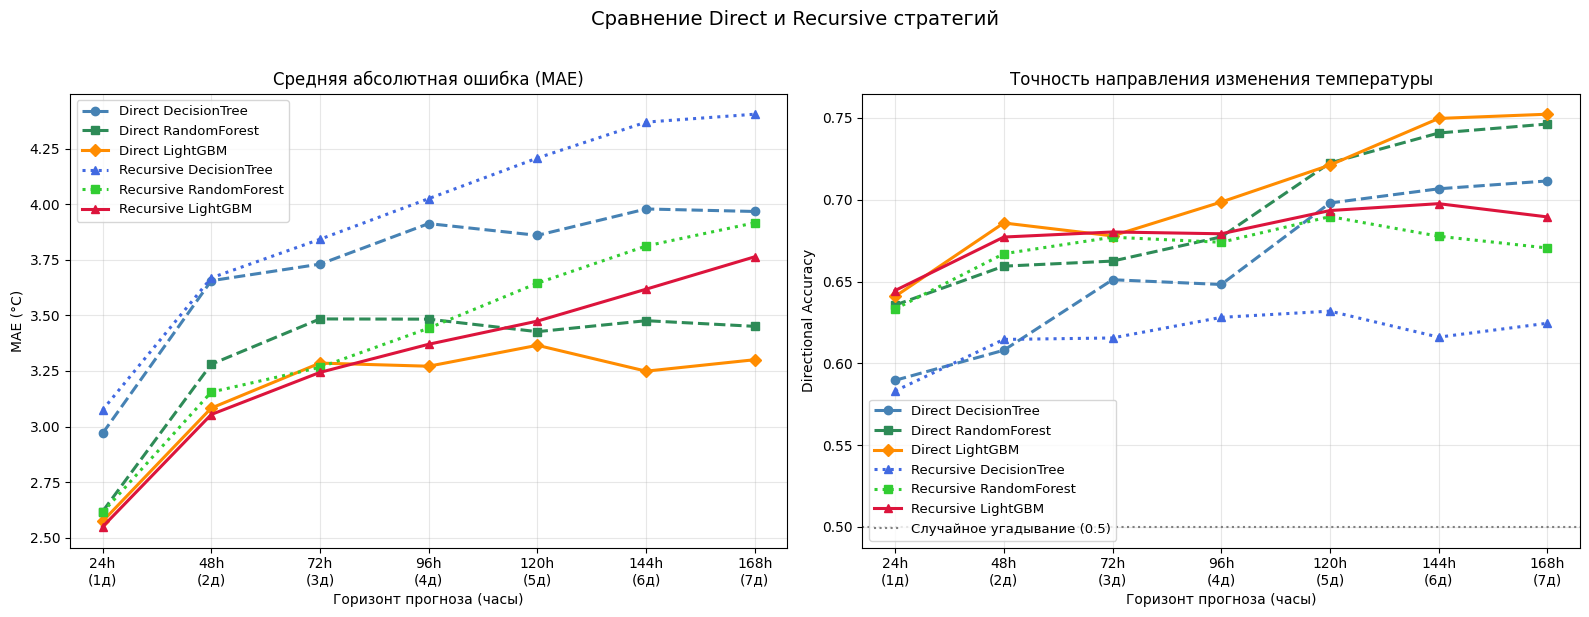

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {
    ('Direct',    'DecisionTree'):  ('steelblue',    '--', 'o'),
    ('Direct',    'RandomForest'):  ('seagreen',     '--', 's'),
    ('Direct',    'LightGBM'):      ('darkorange',   '-',  'D'),

    ('Recursive', 'DecisionTree'):  ('royalblue',    ':',  '^'),
    ('Recursive', 'RandomForest'):  ('limegreen',    ':',  's'),
    ('Recursive', 'LightGBM'):      ('crimson',      '-',  '^'),
}

for (strategy, model), (color, ls, marker) in palette.items():
    sub = results_df[
        (results_df['Стратегия'] == strategy) &
        (results_df['Модель'] == model)
    ]
    if sub.empty:
        continue

    label = f'{strategy} {model}'

    # MAE (чем ниже - тем лучше)
    axes[0].plot(sub['Горизонт (ч)'], sub['MAE'],
                 color=color, ls=ls, marker=marker, lw=2.2, label=label)

    # Directional Accuracy (чем выше, тем лучше)
    axes[1].plot(sub['Горизонт (ч)'], sub['Dir.Acc'],
                 color=color, ls=ls, marker=marker, lw=2.2, label=label)

# MAE
axes[0].set_xlabel('Горизонт прогноза (часы)')
axes[0].set_ylabel('MAE (°C)')
axes[0].set_title('Средняя абсолютная ошибка (MAE)')
axes[0].set_xticks(HORIZONS)
axes[0].set_xticklabels([f'{h}h\n({h//24}д)' for h in HORIZONS])
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9.5, loc='upper left')

# Directional Accuracy
axes[1].axhline(0.5, color='gray', ls=':', lw=1.5, label='Случайное угадывание (0.5)')
axes[1].set_xlabel('Горизонт прогноза (часы)')
axes[1].set_ylabel('Directional Accuracy')
axes[1].set_title('Точность направления изменения температуры')
axes[1].set_xticks(HORIZONS)
axes[1].set_xticklabels([f'{h}h\n({h//24}д)' for h in HORIZONS])
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9.5, loc='lower left')

plt.suptitle('Сравнение Direct и Recursive стратегий', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Выводы из графиков:
- Все модели лучше, чем случайное угадывание.
- В целом лучше всех себя показывает Direct бустинг, но при краткосрочных прогнозах (до 3 дней) рекурсивный бустинг показывает себя лучше.
- Выбор модели больше влияет на результат, чем выбор стратегии.

## Анализ лучшей модели
Рассмотрим самую лучшую модель - LightGBM Direct, проанализируем ее качество с помощью остатков.

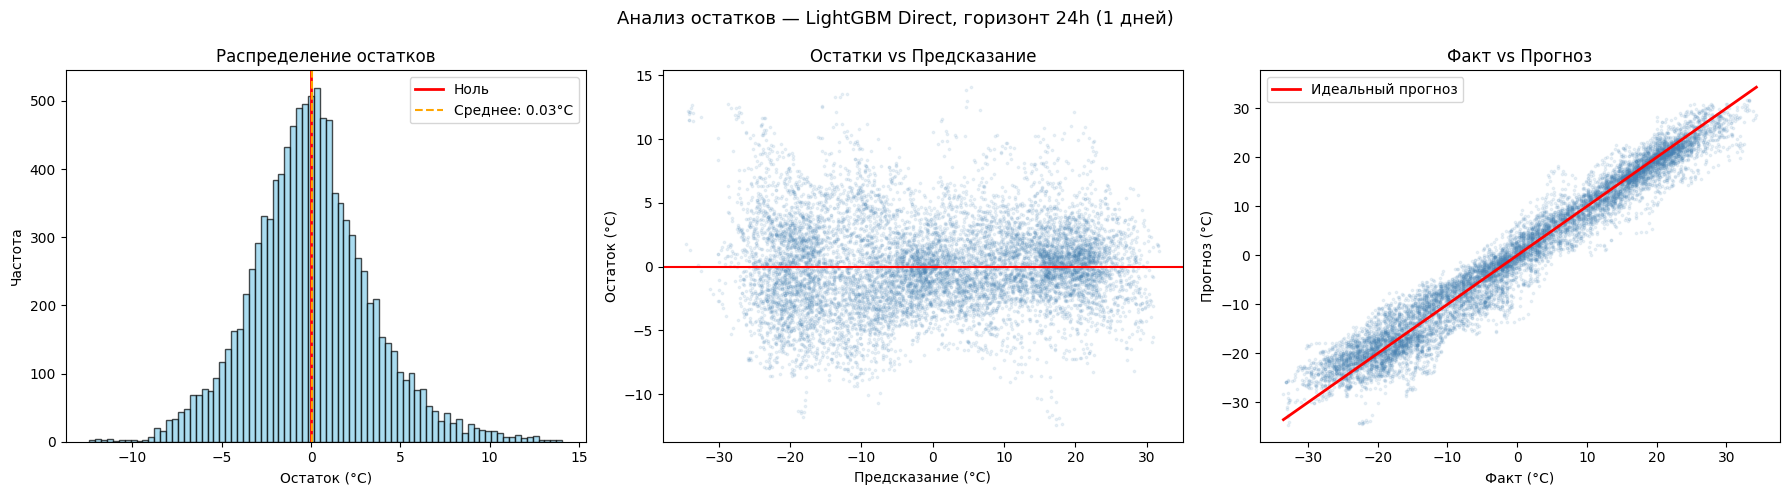

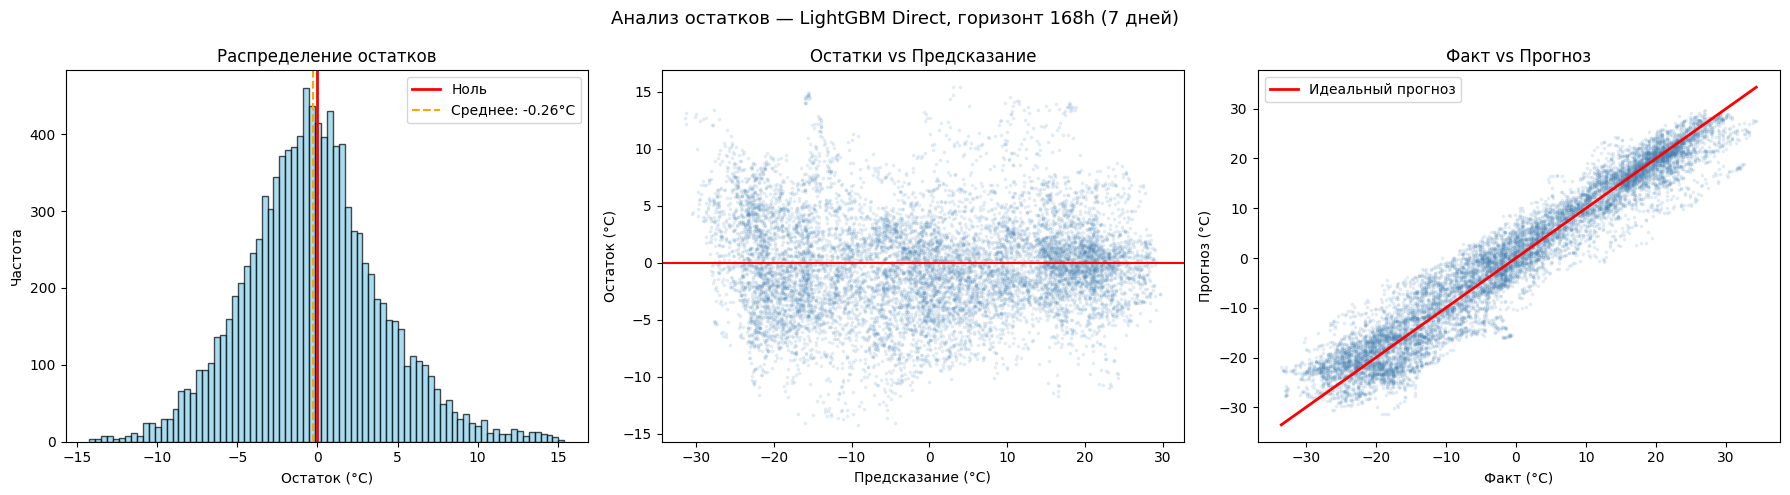

In [ ]:
for h in [24, 168]:
    y_test_h  = test_df[f'target_{h}h'].values
    p_h       = best_lgb_preds[h]
    residuals = y_test_h - p_h

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Анализ остатков — LightGBM Direct, горизонт {h}h ({h//24} дней)', fontsize=13)

    # Гистограмма остатков
    axes[0].hist(residuals, bins=80, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', lw=2, label='Ноль')
    axes[0].axvline(residuals.mean(), color='orange', lw=1.5, ls='--',
                    label=f'Среднее: {residuals.mean():.2f}°C')
    axes[0].set_xlabel('Остаток (°C)')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Распределение остатков')
    axes[0].legend()

    # Остатки vs предсказание
    axes[1].scatter(p_h, residuals, alpha=0.1, s=3, color='steelblue')
    axes[1].axhline(0, color='red', lw=1.5)
    axes[1].set_xlabel('Предсказание (°C)')
    axes[1].set_ylabel('Остаток (°C)')
    axes[1].set_title('Остатки vs Предсказание')

    # Факт vs прогноз
    mn, mx = y_test_h.min(), y_test_h.max()
    axes[2].scatter(y_test_h, p_h, alpha=0.1, s=3, color='steelblue')
    axes[2].plot([mn, mx], [mn, mx], color='red', lw=2, label='Идеальный прогноз')
    axes[2].set_xlabel('Факт (°C)')
    axes[2].set_ylabel('Прогноз (°C)')
    axes[2].set_title('Факт vs Прогноз')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


Видим, что остатки распределены симметрично и не зависят от предсказания, а прогноз и фактическое значение образуют правильную диагональ.